In [56]:
!pip install shap

In [1]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from pytorch_tabnet.tab_model import TabNetClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

### LOADING THE DATA

In [4]:
os.makedirs("results/confusion_matrices", exist_ok=True)
os.makedirs("results/roc_curves", exist_ok=True)

In [7]:
def load_all_projects(DIR):

    projects = {}

    for file in os.listdir(DIR):

        if file.endswith(".csv"):

            name = file.replace(".csv","")

            df = pd.read_csv(os.path.join(DIR, file))

            projects[name] = df

    return projects

DIR = "/content/drive/MyDrive/new datasets/jureczko"

projects = load_all_projects(DIR)

print("Projects loaded:", list(projects.keys()))

Projects loaded: ['lucene-2.4', 'xerces-1.4.4', 'log4j-1.2', 'xalan-2.7', 'ant-1.7', 'synapse-1.2', 'camel-1.6', 'poi-3.0', 'jedit-4.3', 'velocity-1.6', 'ivy-1.0']


In [ ]:
def print_dataset_snapshot(df, name):

    print("\n================================")
    print(name)
    print("================================")

    print("Shape:", df.shape)

    if "label" in df.columns:

        counts = df["label"].value_counts()

        print("Class distribution:")
        print(counts)

### CLEANING

In [8]:
LABEL_ALIASES = {"label","defective","bug","bugs","is_buggy"}

NON_METRIC_COLUMNS = {"name","class","file","module","version"}


def detect_label_column(df):

    for col in df.columns:

        if col.strip().lower() in LABEL_ALIASES:
            return col

    raise ValueError("No label column found")


def clean_dataset(df):

    df = df.copy()

    label_col = detect_label_column(df)

    if label_col != "label":

        df.rename(columns={label_col:"label"}, inplace=True)

    bool_map = {
        "Y":1,"N":0,
        "y":1,"n":0,
        "True":1,"False":0,
        True:1,False:0
    }

    df.replace(bool_map, inplace=True)

    cols_to_drop = [
        col for col in df.columns
        if col.strip().lower() in NON_METRIC_COLUMNS
    ]

    df.drop(columns=cols_to_drop, errors="ignore", inplace=True)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    feature_cols = [c for c in df.columns if c != "label"]

    imputer = SimpleImputer(strategy="median")

    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    df["label"] = (df["label"] > 0).astype(int)

    return df

In [10]:
cleaned_projects = {}

for name, df in projects.items():

    print_dataset_snapshot(df, f"RAW DATASET — {name}")

    df_clean = clean_dataset(df)

    print_dataset_snapshot(df_clean, f"AFTER CLEANING — {name}")

    cleaned_projects[name] = df_clean


RAW DATASET — lucene-2.4
Shape: (340, 22)

AFTER CLEANING — lucene-2.4
Shape: (340, 21)
Class distribution:
label
1    203
0    137
Name: count, dtype: int64

RAW DATASET — xerces-1.4.4
Shape: (588, 22)

AFTER CLEANING — xerces-1.4.4
Shape: (588, 21)
Class distribution:
label
1    437
0    151
Name: count, dtype: int64

RAW DATASET — log4j-1.2
Shape: (205, 22)

AFTER CLEANING — log4j-1.2
Shape: (205, 21)
Class distribution:
label
1    189
0     16
Name: count, dtype: int64

RAW DATASET — xalan-2.7
Shape: (909, 22)

AFTER CLEANING — xalan-2.7
Shape: (909, 21)
Class distribution:
label
1    898
0     11
Name: count, dtype: int64

RAW DATASET — ant-1.7
Shape: (745, 22)

AFTER CLEANING — ant-1.7
Shape: (745, 21)
Class distribution:
label
0    579
1    166
Name: count, dtype: int64

RAW DATASET — synapse-1.2
Shape: (256, 22)

AFTER CLEANING — synapse-1.2
Shape: (256, 21)
Class distribution:
label
0    170
1     86
Name: count, dtype: int64

RAW DATASET — camel-1.6
Shape: (965, 22)

AFTER C

In [11]:
def normalize_project(df):

    scaler = RobustScaler()

    X = df.drop(columns=["label"])
    y = df["label"]

    X_scaled = scaler.fit_transform(X)

    df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

    df_scaled["label"] = y.values

    return df_scaled

In [12]:
normalized_projects = {}

for name, df in cleaned_projects.items():

    df_norm = normalize_project(df)

    print_dataset_snapshot(df_norm, f"AFTER NORMALIZATION — {name}")

    normalized_projects[name] = df_norm


AFTER NORMALIZATION — lucene-2.4
Shape: (340, 21)
Class distribution:
label
1    203
0    137
Name: count, dtype: int64

AFTER NORMALIZATION — xerces-1.4.4
Shape: (588, 21)
Class distribution:
label
1    437
0    151
Name: count, dtype: int64

AFTER NORMALIZATION — log4j-1.2
Shape: (205, 21)
Class distribution:
label
1    189
0     16
Name: count, dtype: int64

AFTER NORMALIZATION — xalan-2.7
Shape: (909, 21)
Class distribution:
label
1    898
0     11
Name: count, dtype: int64

AFTER NORMALIZATION — ant-1.7
Shape: (745, 21)
Class distribution:
label
0    579
1    166
Name: count, dtype: int64

AFTER NORMALIZATION — synapse-1.2
Shape: (256, 21)
Class distribution:
label
0    170
1     86
Name: count, dtype: int64

AFTER NORMALIZATION — camel-1.6
Shape: (965, 21)
Class distribution:
label
0    777
1    188
Name: count, dtype: int64

AFTER NORMALIZATION — poi-3.0
Shape: (442, 21)
Class distribution:
label
1    281
0    161
Name: count, dtype: int64

AFTER NORMALIZATION — jedit-4.3
Shape

In [13]:
def get_common_features(dataframes):

    feature_sets = [
        set(df.columns) - {"label"}
        for df in dataframes
    ]

    common = set.intersection(*feature_sets)

    return sorted(common)


def align_features(train_dfs, test_df):

    all_dfs = train_dfs + [test_df]

    common_features = get_common_features(all_dfs)

    cols = common_features + ["label"]

    aligned_train = [
        df.loc[:,cols].copy()
        for df in train_dfs
    ]

    aligned_test = test_df.loc[:,cols].copy()

    return aligned_train, aligned_test

In [14]:
def extract_X_y(df):

    X = df.drop(columns=["label"]).values
    y = df["label"].values

    return X, y

In [15]:
def get_classifiers(random_state=42):

    models = {

        "LogisticRegression": LogisticRegression(
            max_iter=2000
        ),

        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            random_state=random_state
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=300,
            random_state=random_state
        ),

        "XGBoost": XGBClassifier(
            n_estimators=300,
            eval_metric="logloss",
            use_label_encoder=False,
            random_state=random_state
        )
    }

    return models

In [16]:
def compute_metrics(y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    gmean = geometric_mean_score(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan

    return {
        "Accuracy": accuracy,
        "F1": f1,
        "MCC": mcc,
        "GMean": gmean,
        "AUC": auc
    }

In [17]:
def save_confusion_matrix(y_true, y_pred, model, project):

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot()

    filename = f"results/confusion_matrices/{project}_{model}.png"

    plt.title(f"{project} - {model}")
    plt.savefig(filename)
    plt.close()

    print("Saved:", filename)

In [18]:
def save_roc_curve(y_true, y_prob, model, project):

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure()

    plt.plot(fpr, tpr, label="ROC")

    plt.plot([0,1], [0,1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{project} - {model}")

    plt.legend()

    filename = f"results/roc_curves/{project}_{model}.png"

    plt.savefig(filename)
    plt.close()

    print("Saved:", filename)

## TRADITIONAL

In [19]:
baseline_results = []

for test_project in projects:

    print("\n==============================")
    print("LOPO BASELINE:", test_project)
    print("==============================")

    train_projects = [p for p in projects if p != test_project]

    train_dfs = [normalized_projects[p] for p in train_projects]

    test_df = normalized_projects[test_project]

    aligned_train, aligned_test = align_features(train_dfs, test_df)

    train_df = pd.concat(aligned_train)

    X_train, y_train = extract_X_y(train_df)
    X_test, y_test = extract_X_y(aligned_test)

    selector = VarianceThreshold(0)

    X_train = selector.fit_transform(X_train)
    X_test = selector.transform(X_test)

    smote = SMOTE(random_state=42)

    X_train, y_train = smote.fit_resample(X_train, y_train)

    models = get_classifiers()

    for name, clf in models.items():

        print("Training", name)

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, y_pred, y_prob)

        save_confusion_matrix(y_test, y_pred, name, test_project)
        save_roc_curve(y_test, y_prob, name, test_project)

        baseline_results.append({
            "project": test_project,
            "model": name,
            **metrics
        })


LOPO BASELINE: lucene-2.4
Training LogisticRegression
Saved: results/confusion_matrices/lucene-2.4_LogisticRegression.png
Saved: results/roc_curves/lucene-2.4_LogisticRegression.png
Training RandomForest
Saved: results/confusion_matrices/lucene-2.4_RandomForest.png
Saved: results/roc_curves/lucene-2.4_RandomForest.png
Training LightGBM
[LightGBM] [Info] Number of positive: 2545, number of negative: 2545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3586
[LightGBM] [Info] Number of data points in the train set: 5090, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/lucene-2.4_LightGBM.png
Saved: results/roc_curves/lucene-2.4_LightGBM.png
Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:56:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved: results/confusion_matrices/lucene-2.4_XGBoost.png
Saved: results/roc_curves/lucene-2.4_XGBoost.png

LOPO BASELINE: xerces-1.4.4
Training LogisticRegression
Saved: results/confusion_matrices/xerces-1.4.4_LogisticRegression.png
Saved: results/roc_curves/xerces-1.4.4_LogisticRegression.png
Training RandomForest
Saved: results/confusion_matrices/xerces-1.4.4_RandomForest.png
Saved: results/roc_curves/xerces-1.4.4_RandomForest.png
Training LightGBM
[LightGBM] [Info] Number of positive: 2531, number of negative: 2531
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4003
[LightGBM] [Info] Number of data points in the train set: 5062, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


...

Saved: results/confusion_matrices/velocity-1.6_XGBoost.png
Saved: results/roc_curves/velocity-1.6_XGBoost.png

LOPO BASELINE: ivy-1.0
Training LogisticRegression
Saved: results/confusion_matrices/ivy-1.0_LogisticRegression.png
Saved: results/roc_curves/ivy-1.0_LogisticRegression.png
Training RandomForest
Saved: results/confusion_matrices/ivy-1.0_RandomForest.png
Saved: results/roc_curves/ivy-1.0_RandomForest.png
Training LightGBM
[LightGBM] [Info] Number of positive: 2634, number of negative: 2634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3506
[LightGBM] [Info] Number of data points in the train set: 5268, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/ivy-1.0_LightGBM.png
Saved: results/roc_curves/ivy-1.0_LightGBM.png
Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:57:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved: results/confusion_matrices/ivy-1.0_XGBoost.png
Saved: results/roc_curves/ivy-1.0_XGBoost.png


In [21]:
baseline_df = pd.DataFrame(baseline_results)

baseline_df.to_csv("Traditional_models_results.csv", index=False)

print(baseline_df)

         project               model  Accuracy        F1       MCC     GMean  \
0     lucene-2.4  LogisticRegression  0.594118  0.691964  0.116539  0.511807   
1     lucene-2.4        RandomForest  0.664706  0.703125  0.323673  0.664629   
2     lucene-2.4            LightGBM  0.632353  0.720358  0.204048  0.559115   
3     lucene-2.4             XGBoost  0.676471  0.750000  0.306614  0.620998   
4   xerces-1.4.4  LogisticRegression  0.508503  0.550544  0.195032  0.572054   
5   xerces-1.4.4        RandomForest  0.596939  0.656023  0.304544  0.654305   
6   xerces-1.4.4            LightGBM  0.619048  0.706037  0.215002  0.622313   
7   xerces-1.4.4             XGBoost  0.666667  0.749361  0.289321  0.663013   
8      log4j-1.2  LogisticRegression  0.595122  0.729642  0.118096  0.608581   
9      log4j-1.2        RandomForest  0.512195  0.650350  0.130054  0.607493   
10     log4j-1.2            LightGBM  0.692683  0.813056  0.022373  0.475942   
11     log4j-1.2             XGBoost  0.

### TABNET EMBEDDINGS +  ORIGINAL FEATURES

In [22]:
tabnet_results_small_embed = []

for test_project in projects:

    print("\n==============================")
    print("LOPO TABNET:", test_project)
    print("==============================")

    train_projects = [p for p in projects if p != test_project]

    train_dfs = [normalized_projects[p] for p in train_projects]

    test_df = normalized_projects[test_project]

    aligned_train, aligned_test = align_features(train_dfs, test_df)

    train_df = pd.concat(aligned_train)

    X_train, y_train = extract_X_y(train_df)
    X_test, y_test = extract_X_y(aligned_test)

    selector = VarianceThreshold(0)

    X_train = selector.fit_transform(X_train)
    X_test = selector.transform(X_test)

    tabnet = TabNetClassifier()

    tabnet.fit(
        X_train,
        y_train,
        max_epochs=50,
        patience=10
    )

    train_emb = tabnet.predict_proba(X_train)
    test_emb = tabnet.predict_proba(X_test)


    smote = SMOTE(random_state=42)

    X_train, y_train = smote.fit_resample(X_train, y_train)

    models = get_classifiers()

    for name, clf in models.items():

        model_name = "TabNet_" + name

        print("Training", model_name)

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, y_pred, y_prob)

        save_confusion_matrix(y_test, y_pred, model_name, test_project)
        save_roc_curve(y_test, y_prob, model_name, test_project)

        tabnet_results_small_embed.append({
            "project": test_project,
            "model": model_name,
            **metrics
        })


LOPO TABNET: lucene-2.4


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.70391 |  0:00:00s
epoch 1  | loss: 0.67925 |  0:00:00s
epoch 2  | loss: 0.66928 |  0:00:00s
epoch 3  | loss: 0.65611 |  0:00:00s
epoch 4  | loss: 0.63129 |  0:00:01s
epoch 5  | loss: 0.60867 |  0:00:01s
epoch 6  | loss: 0.60478 |  0:00:01s
epoch 7  | loss: 0.58713 |  0:00:01s
epoch 8  | loss: 0.58944 |  0:00:01s
epoch 9  | loss: 0.58327 |  0:00:02s
epoch 10 | loss: 0.57059 |  0:00:02s
epoch 11 | loss: 0.57206 |  0:00:02s
epoch 12 | loss: 0.5719  |  0:00:02s
epoch 13 | loss: 0.56063 |  0:00:03s
epoch 14 | loss: 0.55964 |  0:00:03s
epoch 15 | loss: 0.55252 |  0:00:03s
epoch 16 | loss: 0.54642 |  0:00:03s
epoch 17 | loss: 0.5577  |  0:00:04s
epoch 18 | loss: 0.55329 |  0:00:04s
epoch 19 | loss: 0.55127 |  0:00:04s
epoch 20 | loss: 0.54279 |  0:00:05s
epoch 21 | loss: 0.54091 |  0:00:05s
epoch 22 | loss: 0.53299 |  0:00:05s
epoch 23 | loss: 0.5363  |  0:00:05s
epoch 24 | loss: 0.52248 |  0:00:06s
epoch 25 | loss: 0.52197 |  0:00:06s
epoch 26 | loss: 0.51749 |  0:00:06s
e

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/lucene-2.4_TabNet_LightGBM.png
Saved: results/roc_curves/lucene-2.4_TabNet_LightGBM.png
Training TabNet_XGBoost


...

epoch 0  | loss: 0.69445 |  0:00:00s
epoch 1  | loss: 0.65981 |  0:00:00s
epoch 2  | loss: 0.63958 |  0:00:00s
epoch 3  | loss: 0.63014 |  0:00:00s
epoch 4  | loss: 0.62601 |  0:00:01s
epoch 5  | loss: 0.59679 |  0:00:01s
epoch 6  | loss: 0.59002 |  0:00:01s
epoch 7  | loss: 0.58546 |  0:00:01s
epoch 8  | loss: 0.58385 |  0:00:02s
epoch 9  | loss: 0.57261 |  0:00:02s
epoch 10 | loss: 0.56634 |  0:00:02s
epoch 11 | loss: 0.56018 |  0:00:02s
epoch 12 | loss: 0.55683 |  0:00:03s
epoch 13 | loss: 0.5513  |  0:00:03s
epoch 14 | loss: 0.5523  |  0:00:03s
epoch 15 | loss: 0.54517 |  0:00:03s
epoch 16 | loss: 0.54982 |  0:00:04s
epoch 17 | loss: 0.53793 |  0:00:04s
epoch 18 | loss: 0.53394 |  0:00:04s
epoch 19 | loss: 0.52966 |  0:00:04s
epoch 20 | loss: 0.51985 |  0:00:05s
epoch 21 | loss: 0.52195 |  0:00:05s
epoch 22 | loss: 0.51241 |  0:00:05s
epoch 23 | loss: 0.5096  |  0:00:05s
epoch 24 | loss: 0.51017 |  0:00:06s
epoch 25 | loss: 0.51304 |  0:00:06s
epoch 26 | loss: 0.50888 |  0:00:07s
e

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/ivy-1.0_TabNet_LightGBM.png
Saved: results/roc_curves/ivy-1.0_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:06:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved: results/confusion_matrices/ivy-1.0_TabNet_XGBoost.png
Saved: results/roc_curves/ivy-1.0_TabNet_XGBoost.png


In [29]:
Tabnet_enriched_df = pd.DataFrame(tabnet_results_small_embed)

Tabnet_enriched_df.to_csv("tabnet_enriched_results.csv", index=False)

print(Tabnet_enriched_df)

         project                      model  Accuracy        F1       MCC  \
0     lucene-2.4  TabNet_LogisticRegression  0.594118  0.691964  0.116539   
1     lucene-2.4        TabNet_RandomForest  0.664706  0.703125  0.323673   
2     lucene-2.4            TabNet_LightGBM  0.632353  0.720358  0.204048   
3     lucene-2.4             TabNet_XGBoost  0.676471  0.750000  0.306614   
4   xerces-1.4.4  TabNet_LogisticRegression  0.508503  0.550544  0.195032   
5   xerces-1.4.4        TabNet_RandomForest  0.596939  0.656023  0.304544   
6   xerces-1.4.4            TabNet_LightGBM  0.619048  0.706037  0.215002   
7   xerces-1.4.4             TabNet_XGBoost  0.666667  0.749361  0.289321   
8      log4j-1.2  TabNet_LogisticRegression  0.595122  0.729642  0.118096   
9      log4j-1.2        TabNet_RandomForest  0.512195  0.650350  0.130054   
10     log4j-1.2            TabNet_LightGBM  0.692683  0.813056  0.022373   
11     log4j-1.2             TabNet_XGBoost  0.687805  0.808383  0.052640   


LOPO TABNET: lucene-2.4


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.37281 |  0:00:01s
epoch 1  | loss: 0.92005 |  0:00:02s
epoch 2  | loss: 0.7875  |  0:00:03s
epoch 3  | loss: 0.76795 |  0:00:05s
epoch 4  | loss: 0.71777 |  0:00:06s
epoch 5  | loss: 0.69009 |  0:00:09s
epoch 6  | loss: 0.68102 |  0:00:11s
epoch 7  | loss: 0.66336 |  0:00:12s
epoch 8  | loss: 0.61731 |  0:00:13s
epoch 9  | loss: 0.61346 |  0:00:15s
epoch 10 | loss: 0.60289 |  0:00:15s
epoch 11 | loss: 0.58646 |  0:00:16s
epoch 12 | loss: 0.58631 |  0:00:16s
epoch 13 | loss: 0.5879  |  0:00:17s
epoch 14 | loss: 0.56602 |  0:00:17s
epoch 15 | loss: 0.55875 |  0:00:18s
epoch 16 | loss: 0.57183 |  0:00:18s
epoch 17 | loss: 0.55642 |  0:00:19s
epoch 18 | loss: 0.54349 |  0:00:20s
epoch 19 | loss: 0.53454 |  0:00:20s
epoch 20 | loss: 0.52548 |  0:00:21s
epoch 21 | loss: 0.53368 |  0:00:21s
epoch 22 | loss: 0.52266 |  0:00:22s
epoch 23 | loss: 0.51777 |  0:00:23s
epoch 24 | loss: 0.52245 |  0:00:23s
epoch 25 | loss: 0.51651 |  0:00:24s
epoch 26 | loss: 0.51789 |  0:00:25s
e

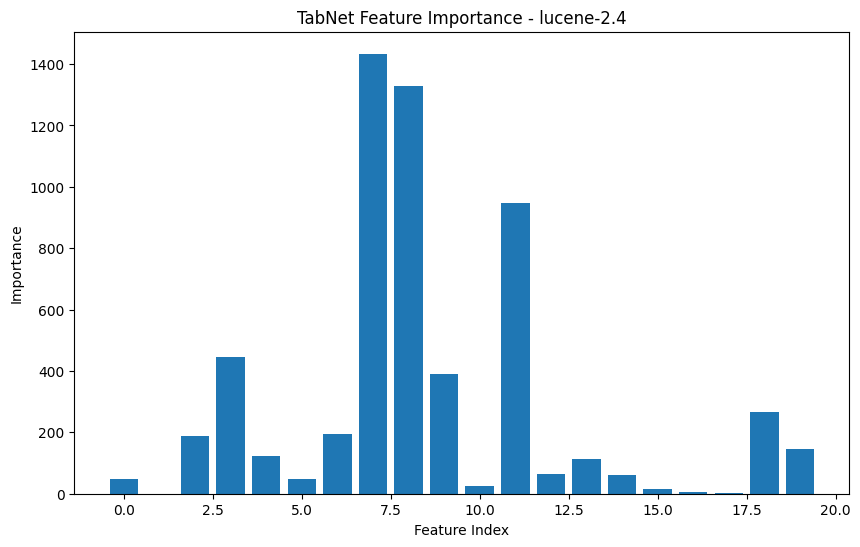

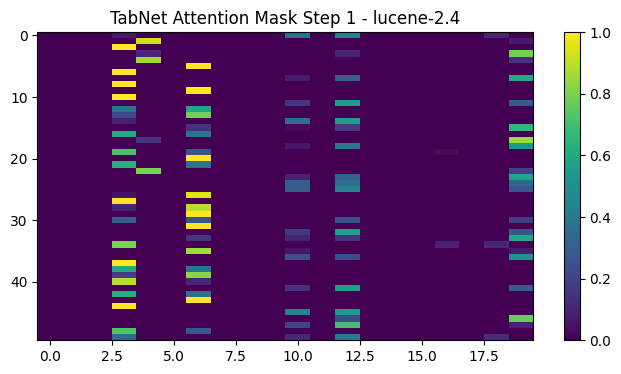

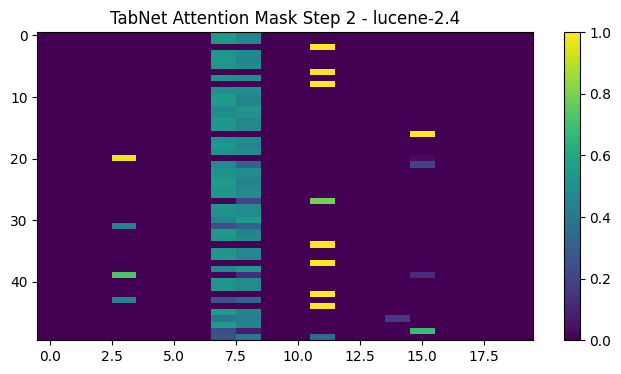

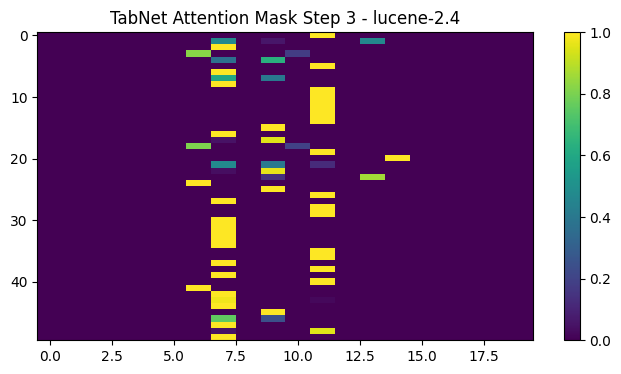

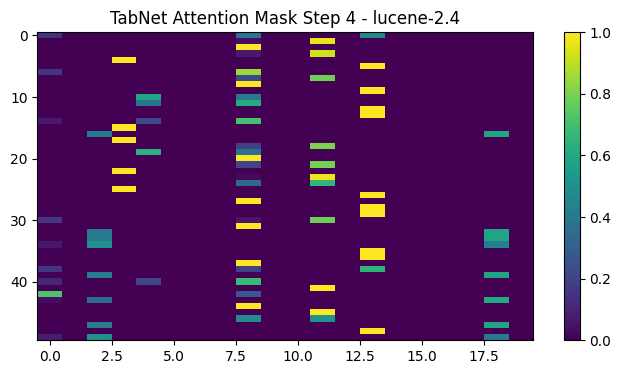

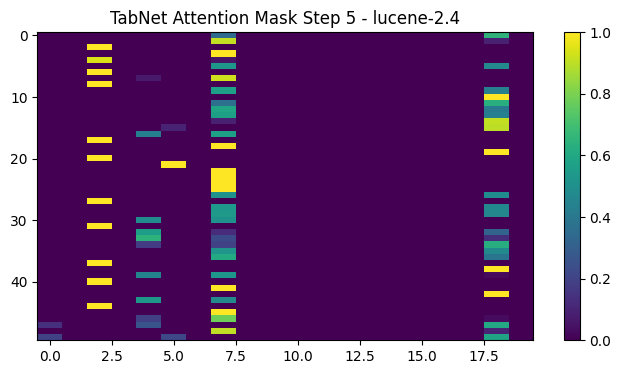

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/lucene-2.4_TabNet_LogisticRegression.png
Saved: results/roc_curves/lucene-2.4_TabNet_LogisticRegression.png
Training TabNet_RandomForest


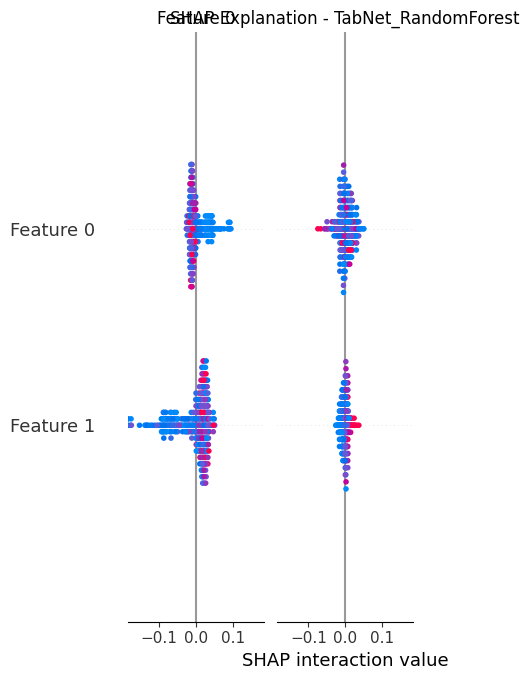

Saved: results/confusion_matrices/lucene-2.4_TabNet_RandomForest.png
Saved: results/roc_curves/lucene-2.4_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2545, number of negative: 2545
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4091
[LightGBM] [Info] Number of data points in the train set: 5090, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


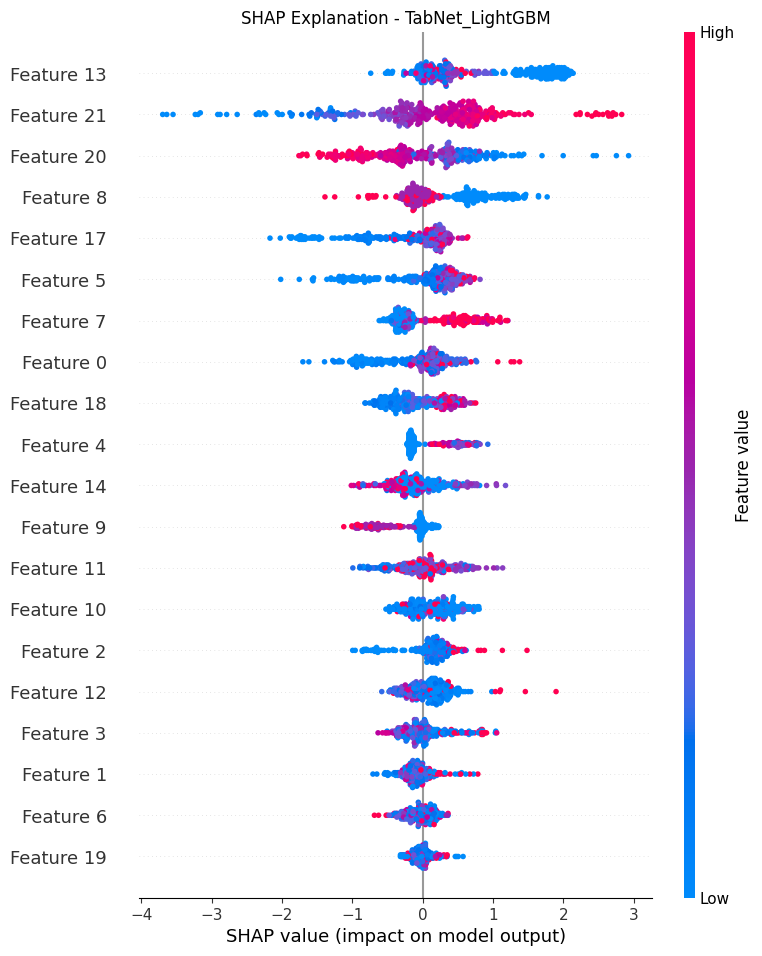

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/lucene-2.4_TabNet_LightGBM.png
Saved: results/roc_curves/lucene-2.4_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:47:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


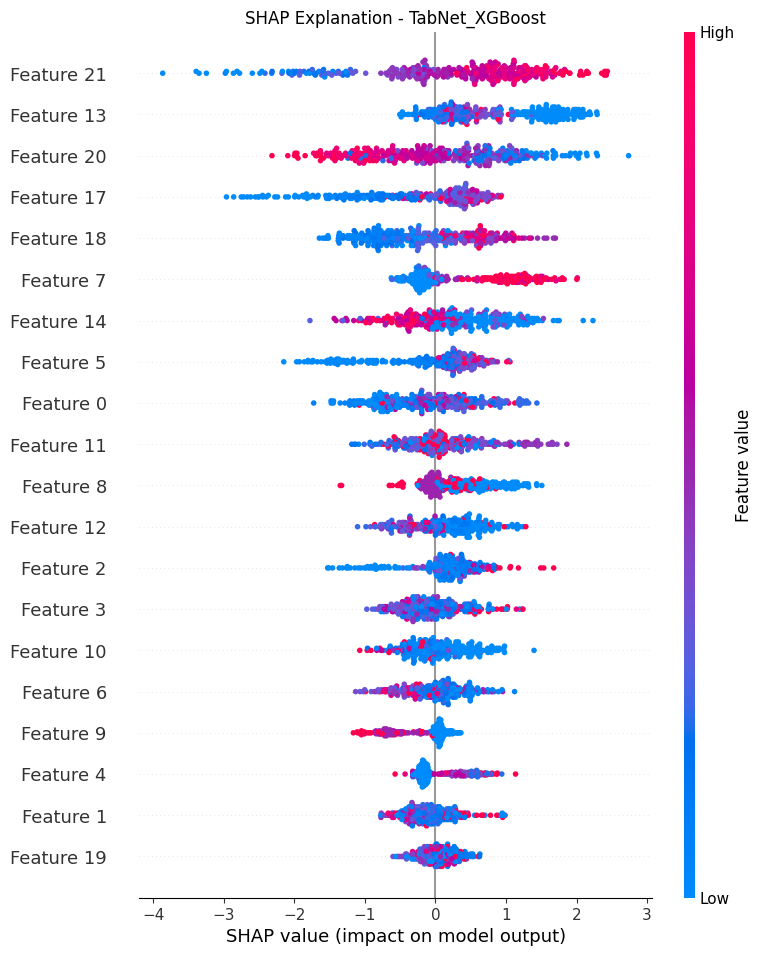

Saved: results/confusion_matrices/lucene-2.4_TabNet_XGBoost.png
Saved: results/roc_curves/lucene-2.4_TabNet_XGBoost.png

LOPO TABNET: xerces-1.4.4


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.2648  |  0:00:00s
epoch 1  | loss: 0.84243 |  0:00:01s
epoch 2  | loss: 0.73176 |  0:00:01s
epoch 3  | loss: 0.69706 |  0:00:02s
epoch 4  | loss: 0.65776 |  0:00:02s
epoch 5  | loss: 0.63537 |  0:00:03s
epoch 6  | loss: 0.64158 |  0:00:03s
epoch 7  | loss: 0.60086 |  0:00:04s
epoch 8  | loss: 0.59014 |  0:00:04s
epoch 9  | loss: 0.59005 |  0:00:05s
epoch 10 | loss: 0.57116 |  0:00:05s
epoch 11 | loss: 0.57574 |  0:00:06s
epoch 12 | loss: 0.55976 |  0:00:07s
epoch 13 | loss: 0.55599 |  0:00:08s
epoch 14 | loss: 0.5473  |  0:00:09s
epoch 15 | loss: 0.54105 |  0:00:09s
epoch 16 | loss: 0.53796 |  0:00:10s
epoch 17 | loss: 0.5261  |  0:00:11s
epoch 18 | loss: 0.5369  |  0:00:12s
epoch 19 | loss: 0.53396 |  0:00:12s
epoch 20 | loss: 0.52779 |  0:00:13s
epoch 21 | loss: 0.53105 |  0:00:13s
epoch 22 | loss: 0.51986 |  0:00:14s
epoch 23 | loss: 0.52114 |  0:00:14s
epoch 24 | loss: 0.51524 |  0:00:15s
epoch 25 | loss: 0.51501 |  0:00:15s
epoch 26 | loss: 0.50639 |  0:00:16s
e

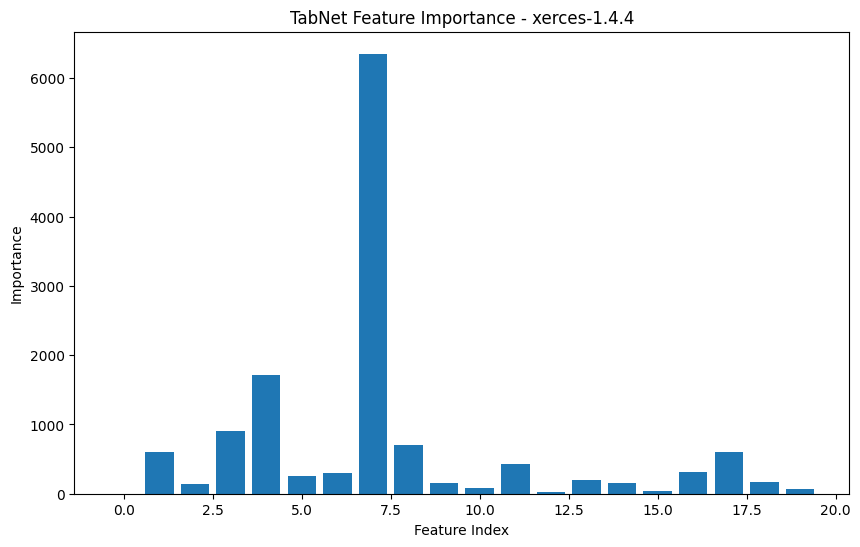

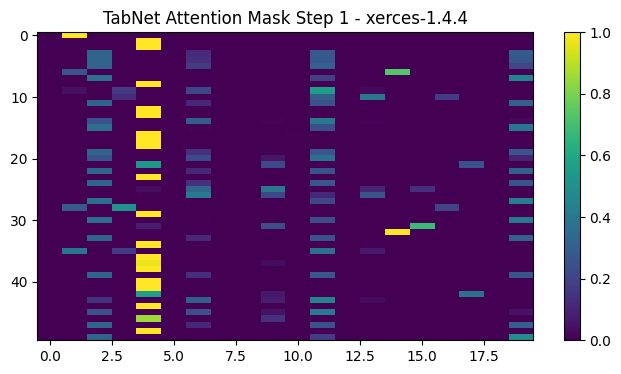

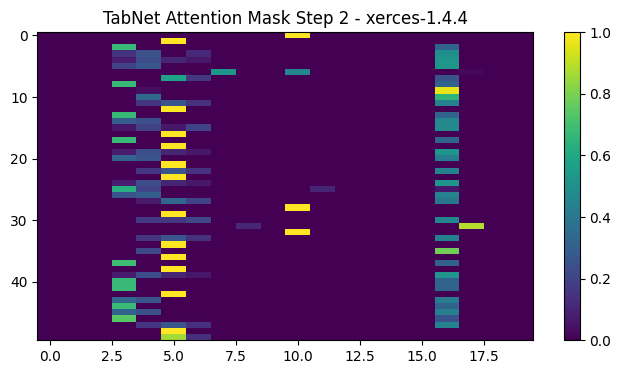

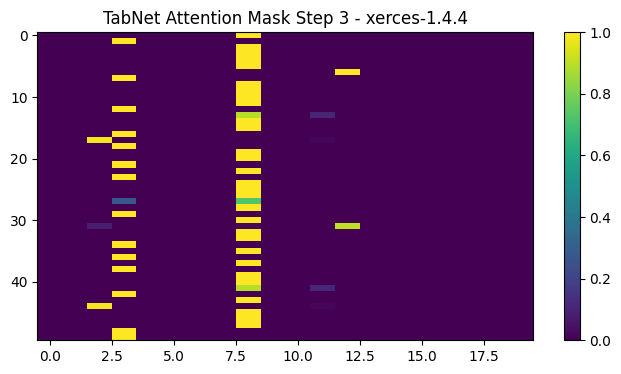

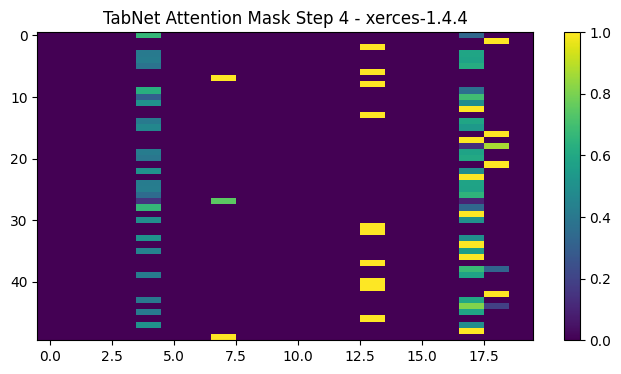

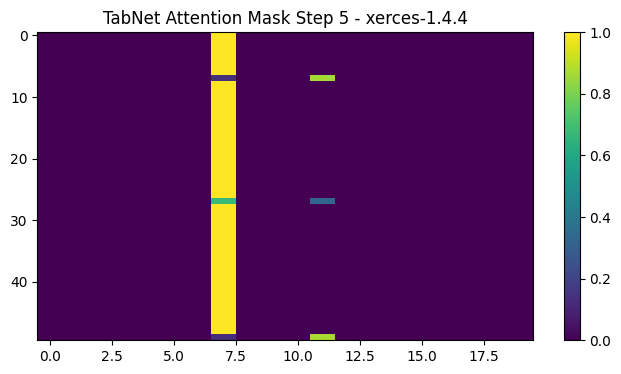

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/xerces-1.4.4_TabNet_LogisticRegression.png
Saved: results/roc_curves/xerces-1.4.4_TabNet_LogisticRegression.png
Training TabNet_RandomForest


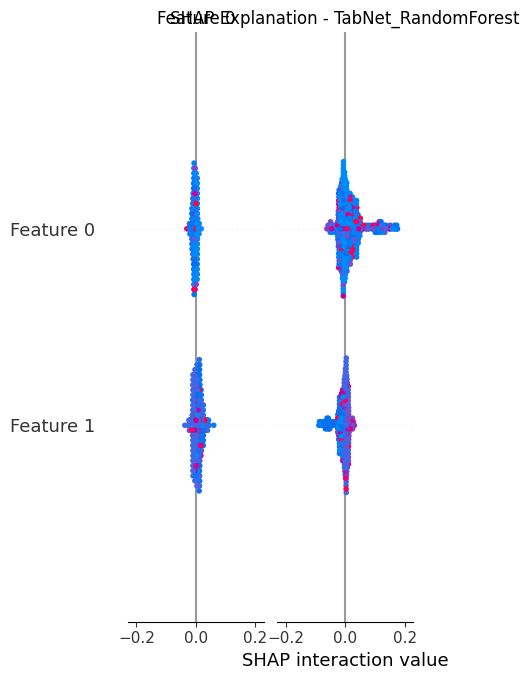

Saved: results/confusion_matrices/xerces-1.4.4_TabNet_RandomForest.png
Saved: results/roc_curves/xerces-1.4.4_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2531, number of negative: 2531
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4518
[LightGBM] [Info] Number of data points in the train set: 5062, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


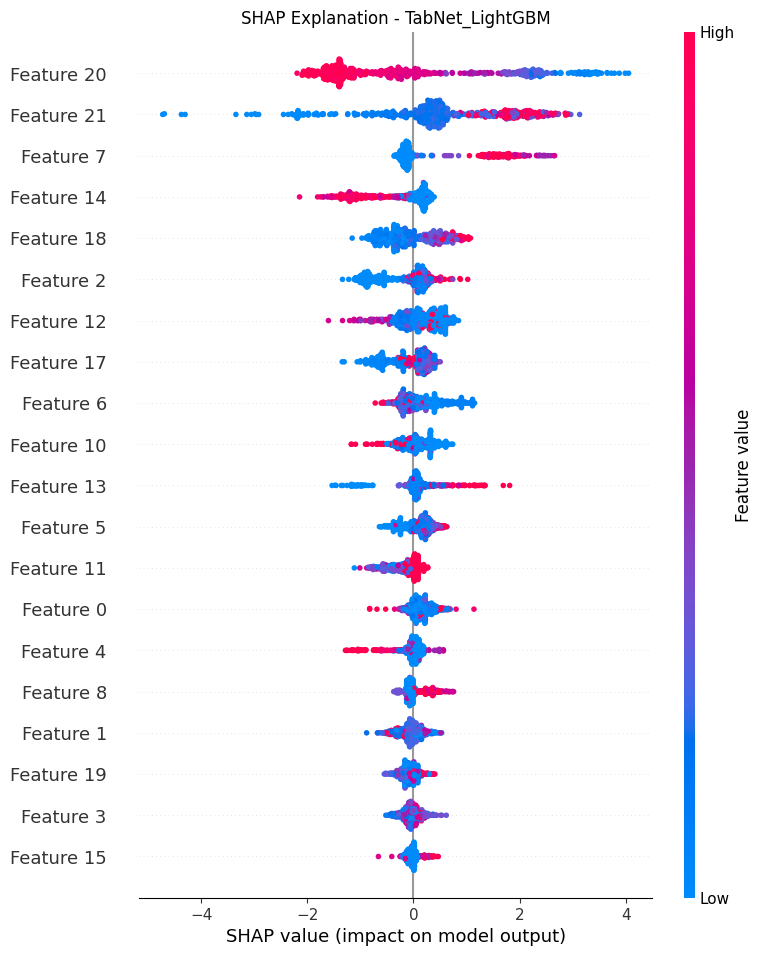

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/xerces-1.4.4_TabNet_LightGBM.png
Saved: results/roc_curves/xerces-1.4.4_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:50:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


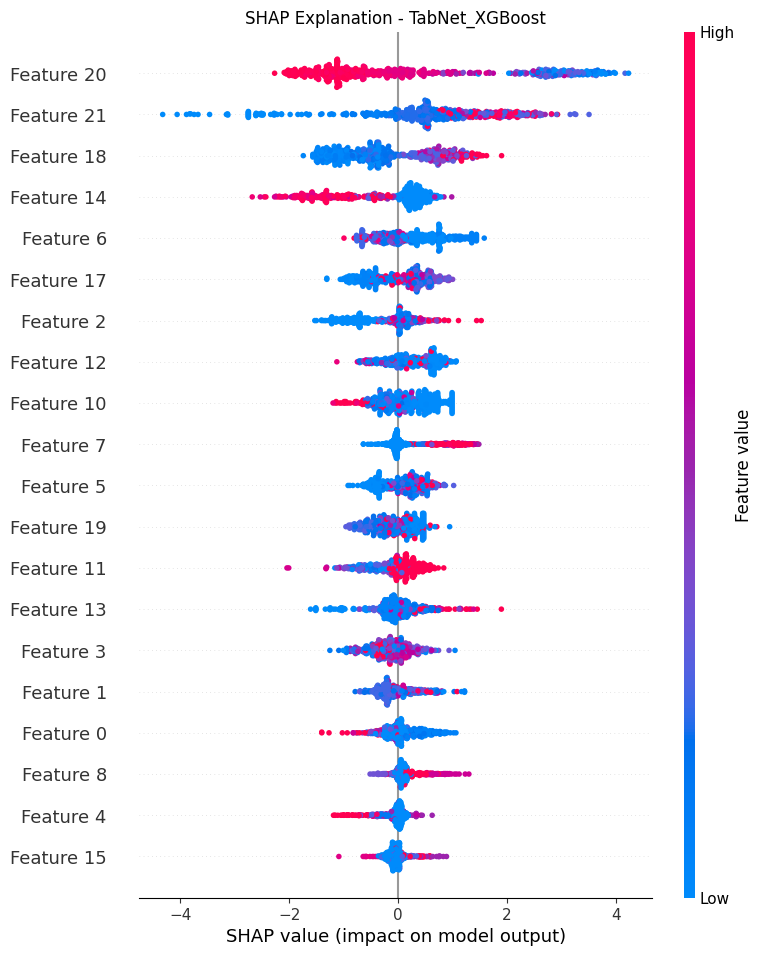

Saved: results/confusion_matrices/xerces-1.4.4_TabNet_XGBoost.png
Saved: results/roc_curves/xerces-1.4.4_TabNet_XGBoost.png

LOPO TABNET: log4j-1.2


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.36883 |  0:00:00s
epoch 1  | loss: 0.91471 |  0:00:01s
epoch 2  | loss: 0.78397 |  0:00:01s
epoch 3  | loss: 0.7856  |  0:00:02s
epoch 4  | loss: 0.71966 |  0:00:03s
epoch 5  | loss: 0.686   |  0:00:03s
epoch 6  | loss: 0.63592 |  0:00:04s
epoch 7  | loss: 0.61636 |  0:00:04s
epoch 8  | loss: 0.62216 |  0:00:05s
epoch 9  | loss: 0.6089  |  0:00:05s
epoch 10 | loss: 0.6171  |  0:00:06s
epoch 11 | loss: 0.60926 |  0:00:06s
epoch 12 | loss: 0.57902 |  0:00:07s
epoch 13 | loss: 0.5891  |  0:00:08s
epoch 14 | loss: 0.56772 |  0:00:08s
epoch 15 | loss: 0.56697 |  0:00:09s
epoch 16 | loss: 0.56795 |  0:00:09s
epoch 17 | loss: 0.56334 |  0:00:10s
epoch 18 | loss: 0.55972 |  0:00:11s
epoch 19 | loss: 0.57566 |  0:00:11s
epoch 20 | loss: 0.56974 |  0:00:12s
epoch 21 | loss: 0.55408 |  0:00:13s
epoch 22 | loss: 0.56003 |  0:00:14s
epoch 23 | loss: 0.54183 |  0:00:15s
epoch 24 | loss: 0.54253 |  0:00:15s
epoch 25 | loss: 0.53652 |  0:00:16s
epoch 26 | loss: 0.53059 |  0:00:17s
e

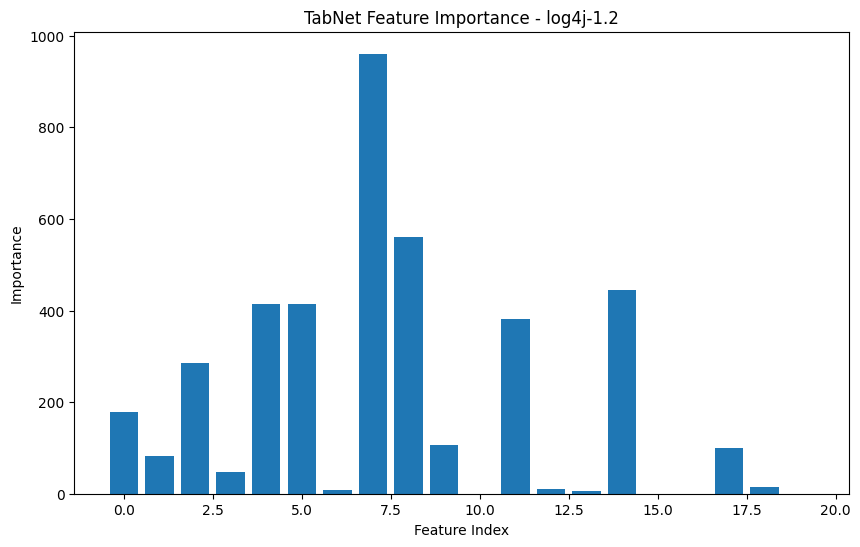

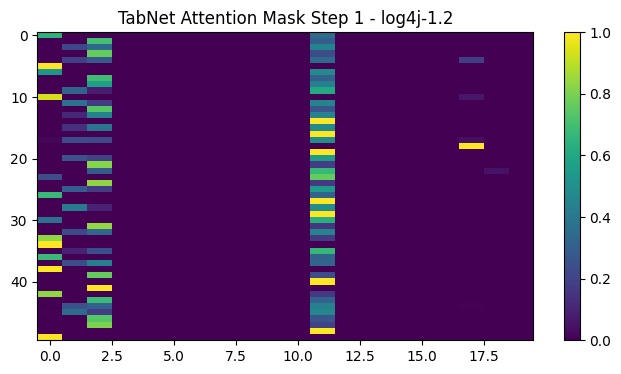

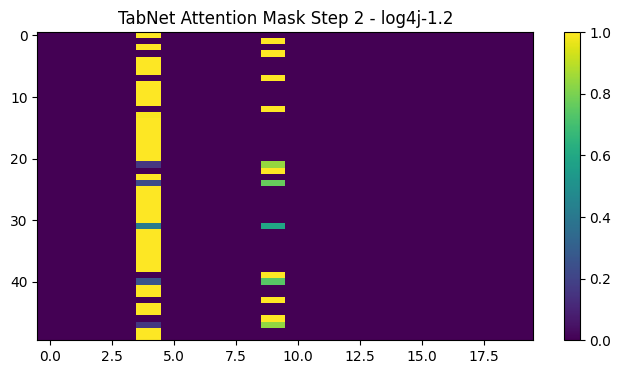

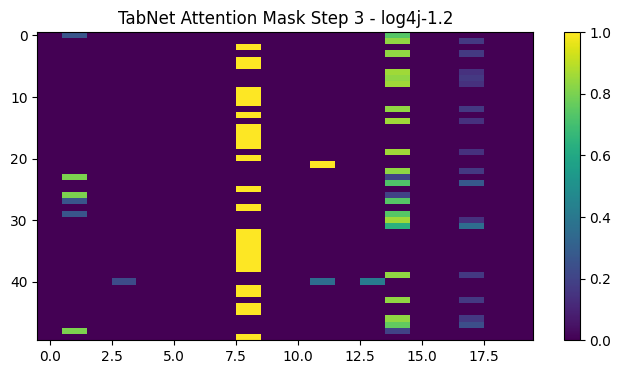

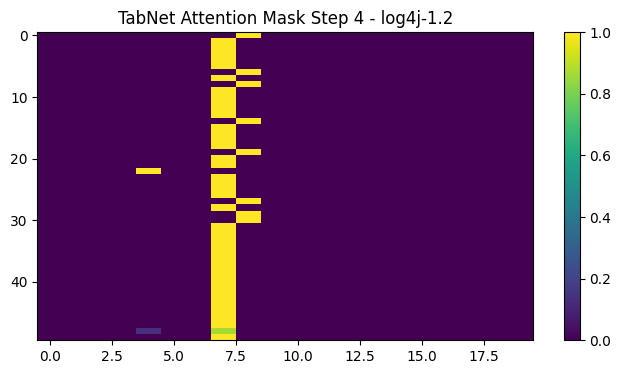

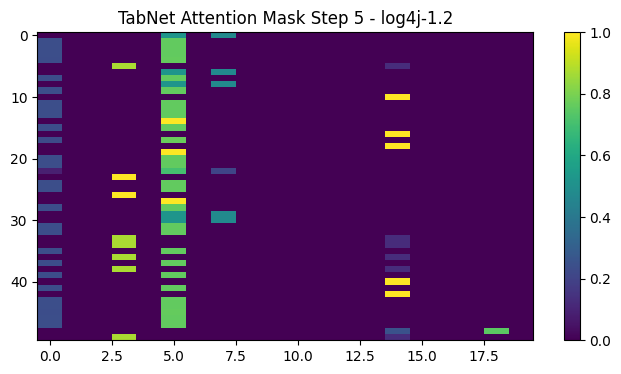

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/log4j-1.2_TabNet_LogisticRegression.png
Saved: results/roc_curves/log4j-1.2_TabNet_LogisticRegression.png
Training TabNet_RandomForest


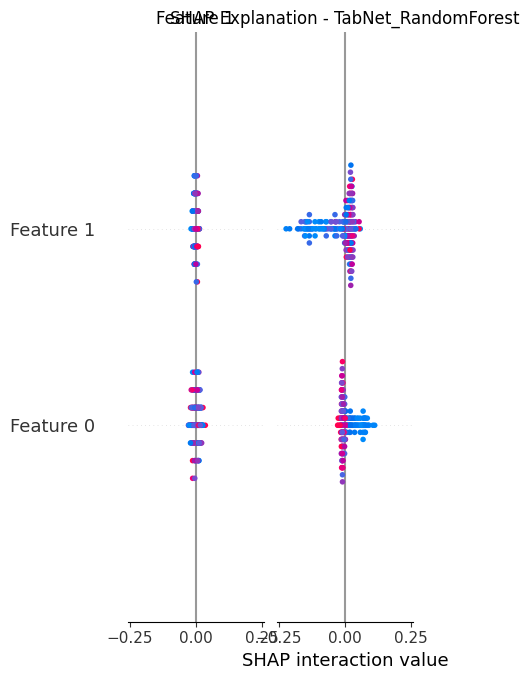

Saved: results/confusion_matrices/log4j-1.2_TabNet_RandomForest.png
Saved: results/roc_curves/log4j-1.2_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2666, number of negative: 2666
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4423
[LightGBM] [Info] Number of data points in the train set: 5332, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


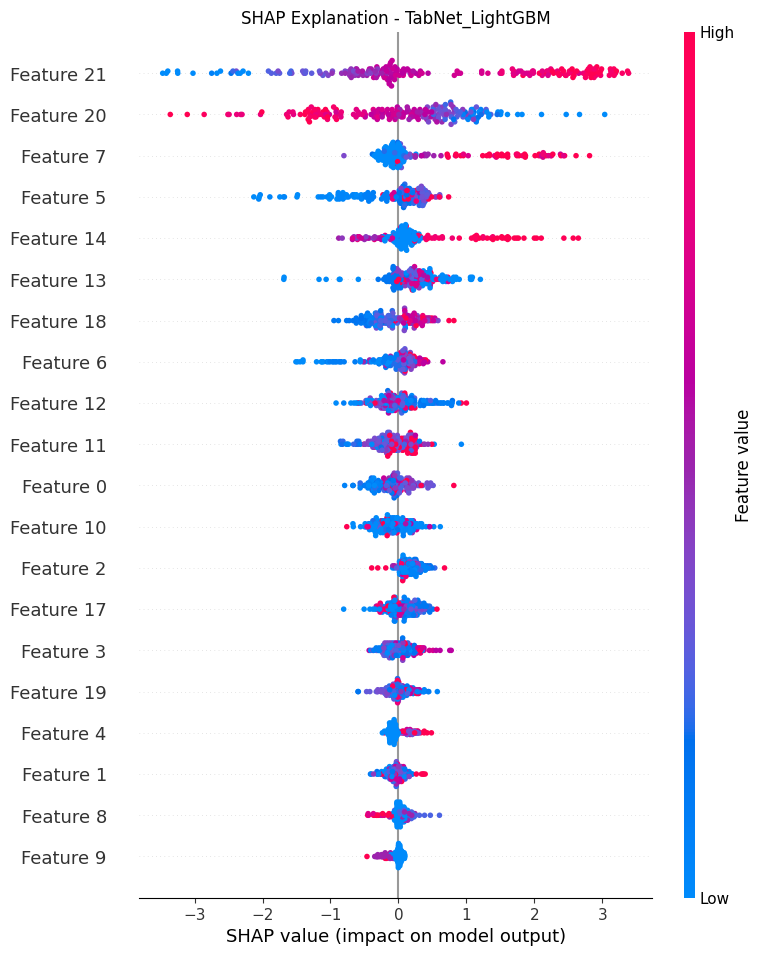

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/log4j-1.2_TabNet_LightGBM.png
Saved: results/roc_curves/log4j-1.2_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


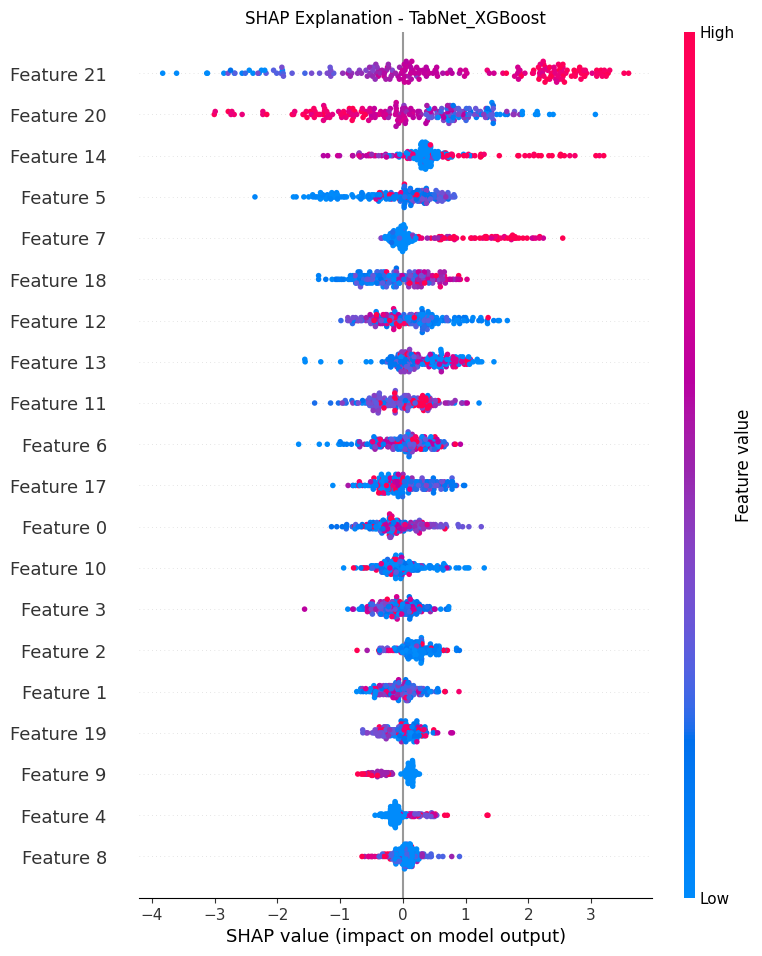

Saved: results/confusion_matrices/log4j-1.2_TabNet_XGBoost.png
Saved: results/roc_curves/log4j-1.2_TabNet_XGBoost.png

LOPO TABNET: xalan-2.7


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.14696 |  0:00:00s
epoch 1  | loss: 0.8682  |  0:00:01s
epoch 2  | loss: 0.82995 |  0:00:01s
epoch 3  | loss: 0.75571 |  0:00:02s
epoch 4  | loss: 0.74278 |  0:00:02s
epoch 5  | loss: 0.72616 |  0:00:03s
epoch 6  | loss: 0.68981 |  0:00:03s
epoch 7  | loss: 0.64868 |  0:00:04s
epoch 8  | loss: 0.67035 |  0:00:05s
epoch 9  | loss: 0.65571 |  0:00:05s
epoch 10 | loss: 0.64297 |  0:00:06s
epoch 11 | loss: 0.63018 |  0:00:06s
epoch 12 | loss: 0.60965 |  0:00:07s
epoch 13 | loss: 0.59962 |  0:00:08s
epoch 14 | loss: 0.59389 |  0:00:09s
epoch 15 | loss: 0.59836 |  0:00:10s
epoch 16 | loss: 0.59478 |  0:00:10s
epoch 17 | loss: 0.59316 |  0:00:11s
epoch 18 | loss: 0.59669 |  0:00:12s
epoch 19 | loss: 0.58971 |  0:00:12s
epoch 20 | loss: 0.58919 |  0:00:13s
epoch 21 | loss: 0.58148 |  0:00:13s
epoch 22 | loss: 0.58502 |  0:00:14s
epoch 23 | loss: 0.5871  |  0:00:14s
epoch 24 | loss: 0.58252 |  0:00:15s
epoch 25 | loss: 0.5723  |  0:00:16s
epoch 26 | loss: 0.57342 |  0:00:16s
e

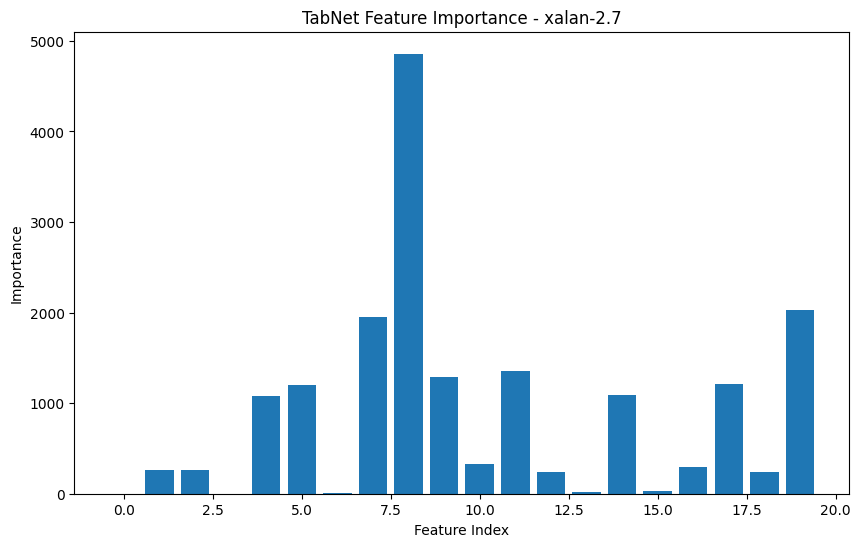

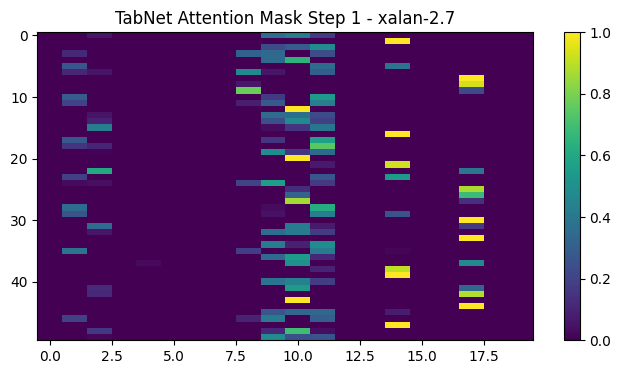

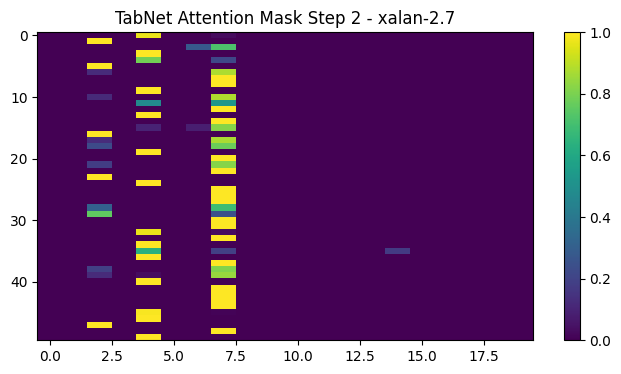

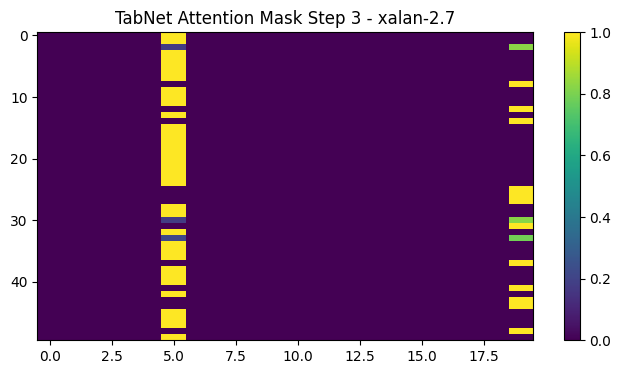

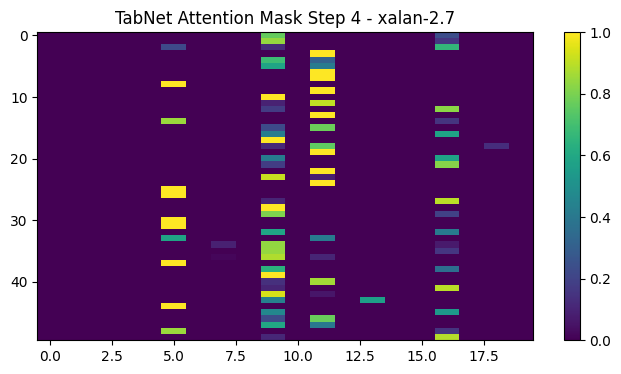

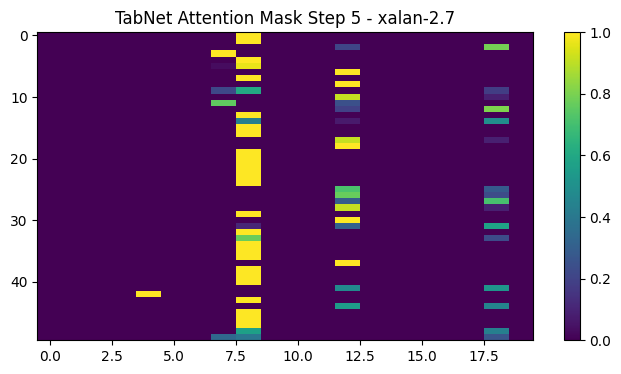

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/xalan-2.7_TabNet_LogisticRegression.png
Saved: results/roc_curves/xalan-2.7_TabNet_LogisticRegression.png
Training TabNet_RandomForest


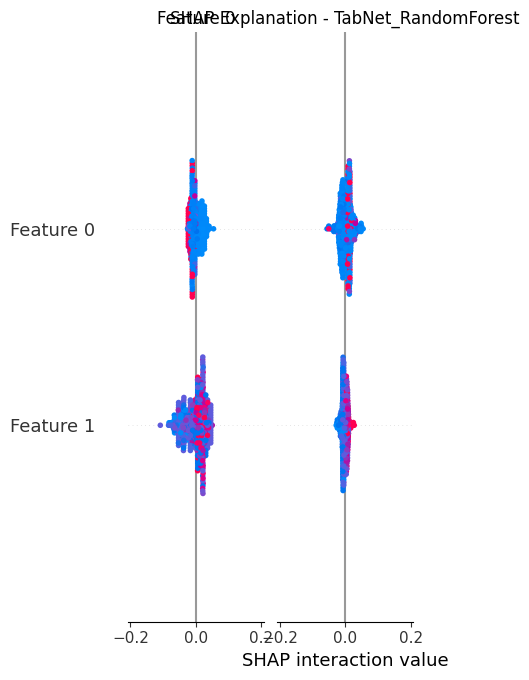

Saved: results/confusion_matrices/xalan-2.7_TabNet_RandomForest.png
Saved: results/roc_curves/xalan-2.7_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2671, number of negative: 2671
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5218
[LightGBM] [Info] Number of data points in the train set: 5342, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


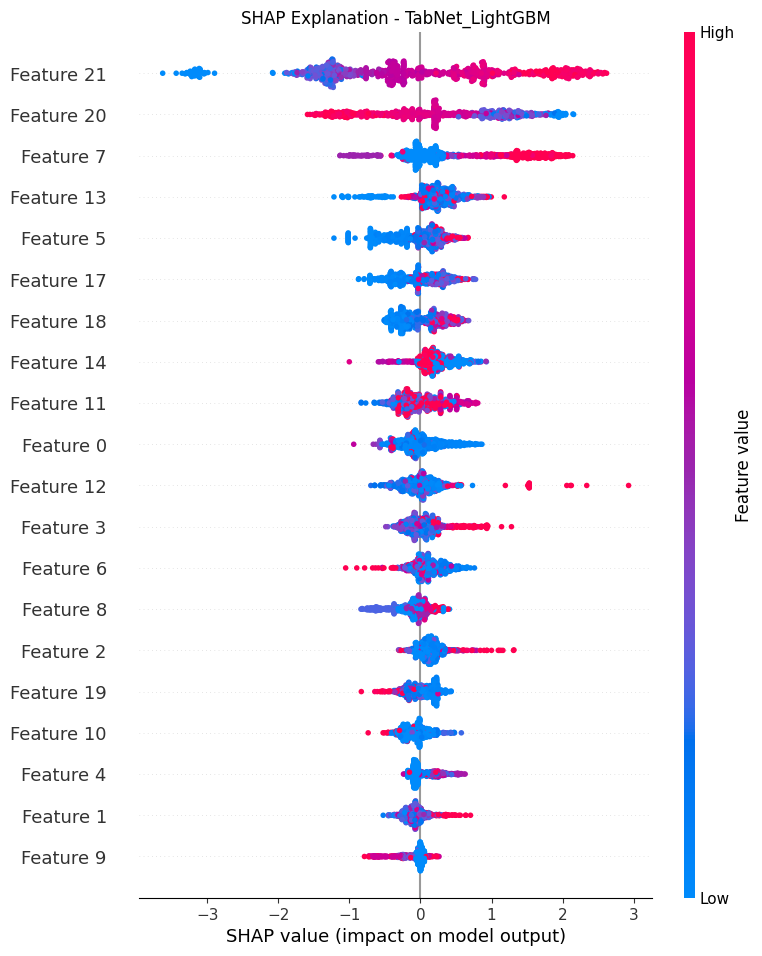

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/xalan-2.7_TabNet_LightGBM.png
Saved: results/roc_curves/xalan-2.7_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:56:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


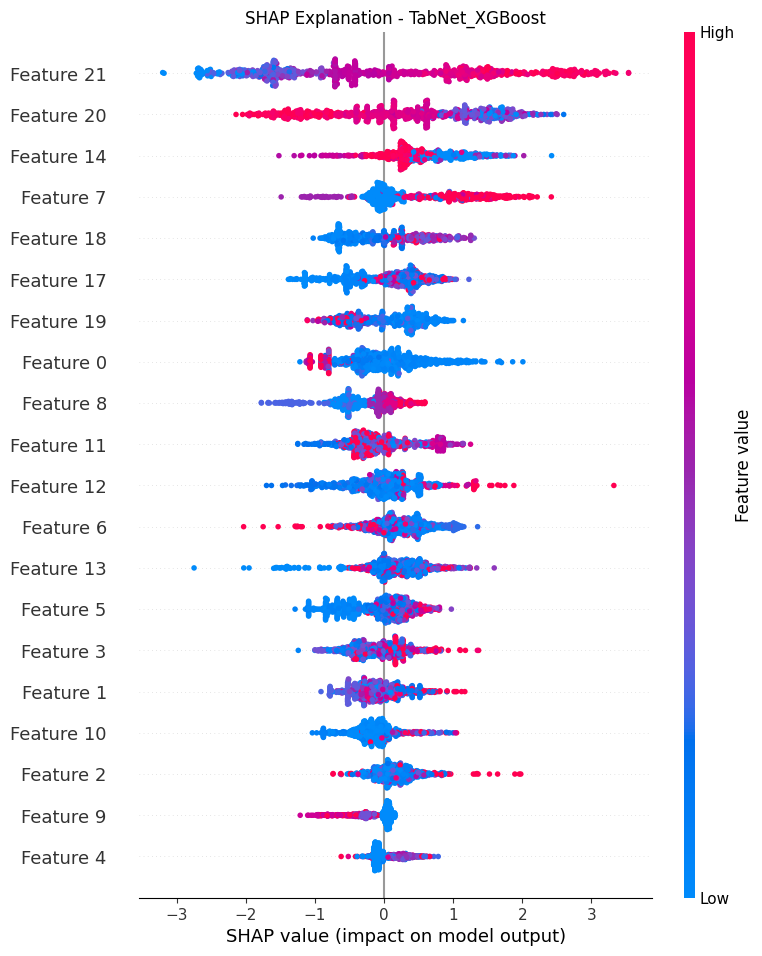

Saved: results/confusion_matrices/xalan-2.7_TabNet_XGBoost.png
Saved: results/roc_curves/xalan-2.7_TabNet_XGBoost.png

LOPO TABNET: ant-1.7


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.40849 |  0:00:00s
epoch 1  | loss: 1.236   |  0:00:01s
epoch 2  | loss: 0.8789  |  0:00:01s
epoch 3  | loss: 0.74782 |  0:00:02s
epoch 4  | loss: 0.71906 |  0:00:02s
epoch 5  | loss: 0.69065 |  0:00:03s
epoch 6  | loss: 0.65578 |  0:00:04s
epoch 7  | loss: 0.61177 |  0:00:04s
epoch 8  | loss: 0.62339 |  0:00:05s
epoch 9  | loss: 0.60247 |  0:00:05s
epoch 10 | loss: 0.59391 |  0:00:06s
epoch 11 | loss: 0.57815 |  0:00:06s
epoch 12 | loss: 0.57222 |  0:00:07s
epoch 13 | loss: 0.56464 |  0:00:07s
epoch 14 | loss: 0.5531  |  0:00:08s
epoch 15 | loss: 0.54579 |  0:00:09s
epoch 16 | loss: 0.54342 |  0:00:09s
epoch 17 | loss: 0.54204 |  0:00:10s
epoch 18 | loss: 0.54224 |  0:00:11s
epoch 19 | loss: 0.54019 |  0:00:12s
epoch 20 | loss: 0.53765 |  0:00:13s
epoch 21 | loss: 0.52638 |  0:00:13s
epoch 22 | loss: 0.534   |  0:00:14s
epoch 23 | loss: 0.52587 |  0:00:15s
epoch 24 | loss: 0.51694 |  0:00:15s
epoch 25 | loss: 0.50574 |  0:00:16s
epoch 26 | loss: 0.51191 |  0:00:17s
e

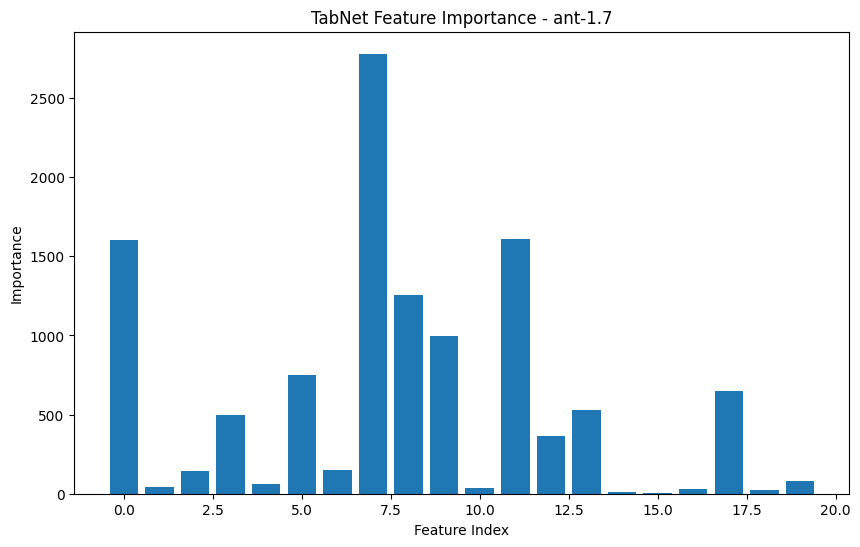

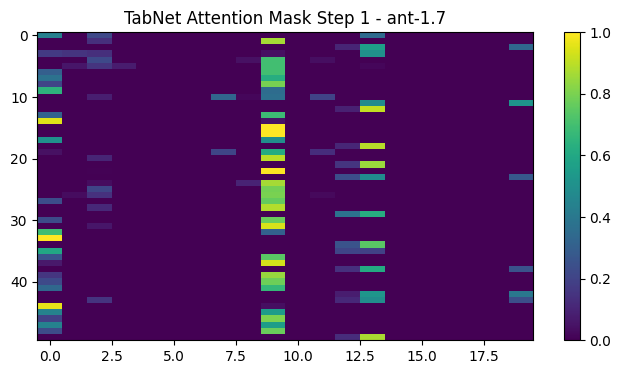

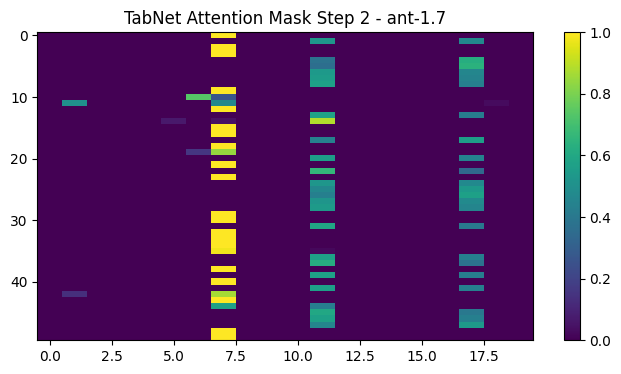

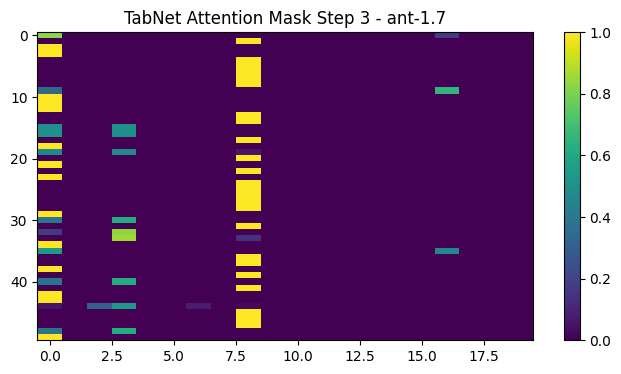

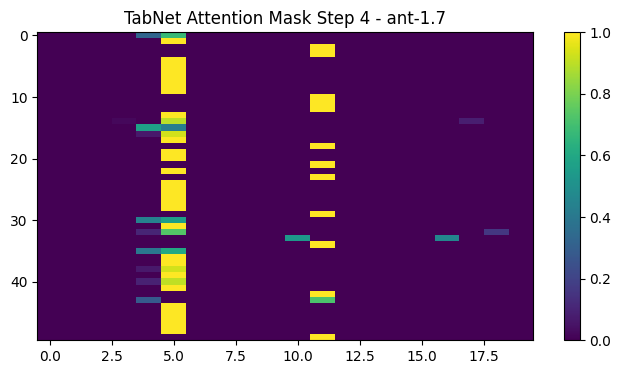

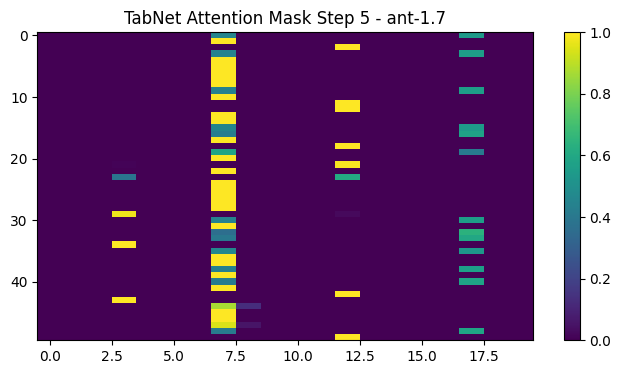

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/ant-1.7_TabNet_LogisticRegression.png
Saved: results/roc_curves/ant-1.7_TabNet_LogisticRegression.png
Training TabNet_RandomForest


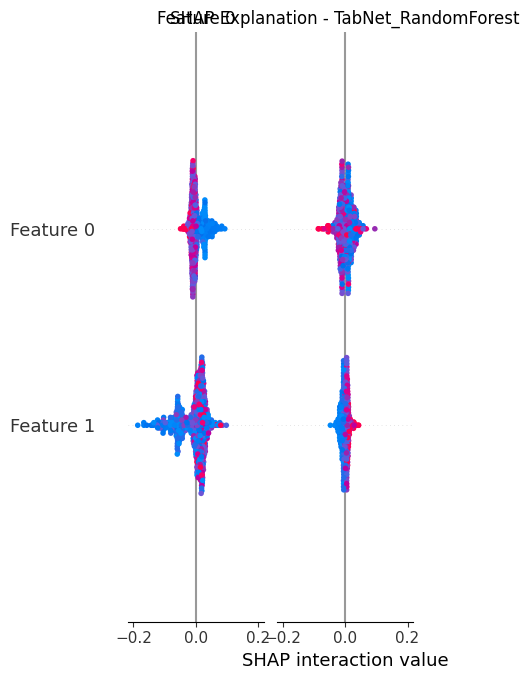

Saved: results/confusion_matrices/ant-1.7_TabNet_RandomForest.png
Saved: results/roc_curves/ant-1.7_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2434, number of negative: 2434
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4449
[LightGBM] [Info] Number of data points in the train set: 4868, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


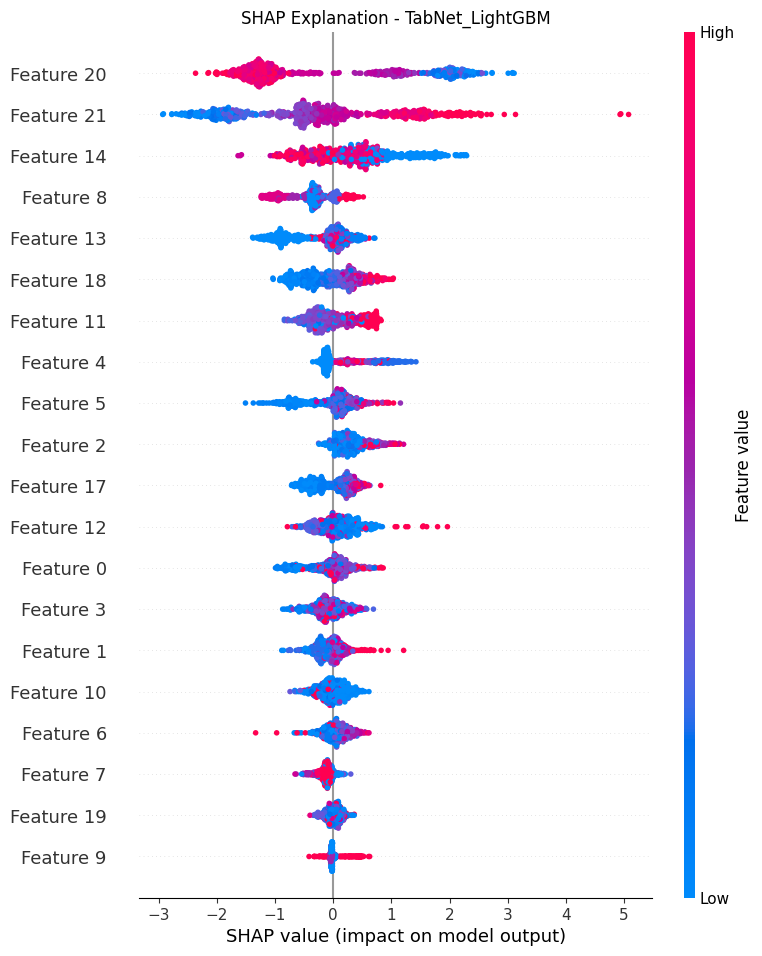

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/ant-1.7_TabNet_LightGBM.png
Saved: results/roc_curves/ant-1.7_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:59:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


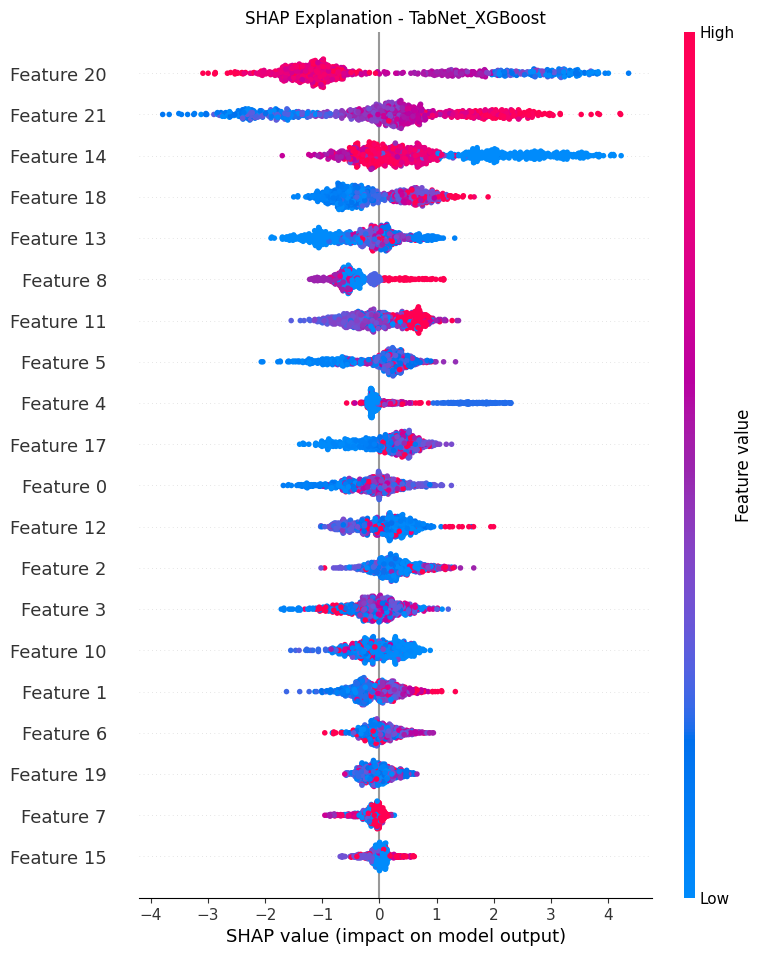

Saved: results/confusion_matrices/ant-1.7_TabNet_XGBoost.png
Saved: results/roc_curves/ant-1.7_TabNet_XGBoost.png

LOPO TABNET: synapse-1.2


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.26616 |  0:00:00s
epoch 1  | loss: 0.81287 |  0:00:01s
epoch 2  | loss: 0.75902 |  0:00:01s
epoch 3  | loss: 0.70773 |  0:00:02s
epoch 4  | loss: 0.70869 |  0:00:02s
epoch 5  | loss: 0.6726  |  0:00:03s
epoch 6  | loss: 0.68584 |  0:00:04s
epoch 7  | loss: 0.63909 |  0:00:04s
epoch 8  | loss: 0.61404 |  0:00:05s
epoch 9  | loss: 0.61776 |  0:00:05s
epoch 10 | loss: 0.62231 |  0:00:06s
epoch 11 | loss: 0.60887 |  0:00:06s
epoch 12 | loss: 0.59615 |  0:00:07s
epoch 13 | loss: 0.58484 |  0:00:07s
epoch 14 | loss: 0.58779 |  0:00:08s
epoch 15 | loss: 0.58837 |  0:00:09s
epoch 16 | loss: 0.58397 |  0:00:09s
epoch 17 | loss: 0.56699 |  0:00:10s
epoch 18 | loss: 0.55844 |  0:00:11s
epoch 19 | loss: 0.55423 |  0:00:12s
epoch 20 | loss: 0.56763 |  0:00:12s
epoch 21 | loss: 0.55003 |  0:00:13s
epoch 22 | loss: 0.55514 |  0:00:14s
epoch 23 | loss: 0.55318 |  0:00:15s
epoch 24 | loss: 0.54665 |  0:00:15s
epoch 25 | loss: 0.53935 |  0:00:16s
epoch 26 | loss: 0.53219 |  0:00:17s
e

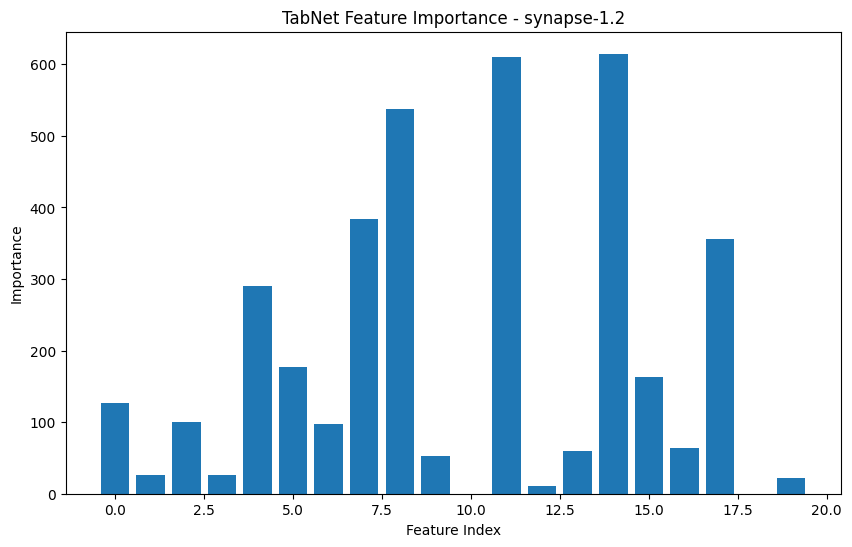

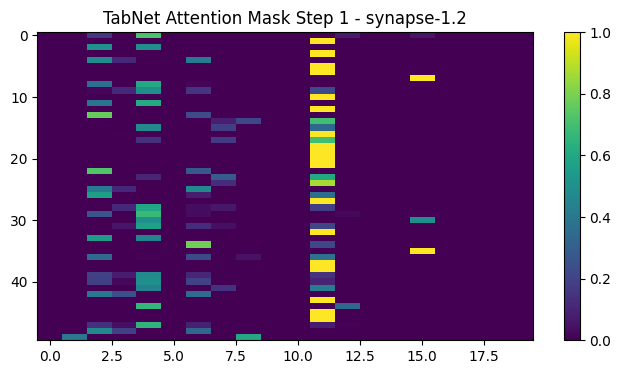

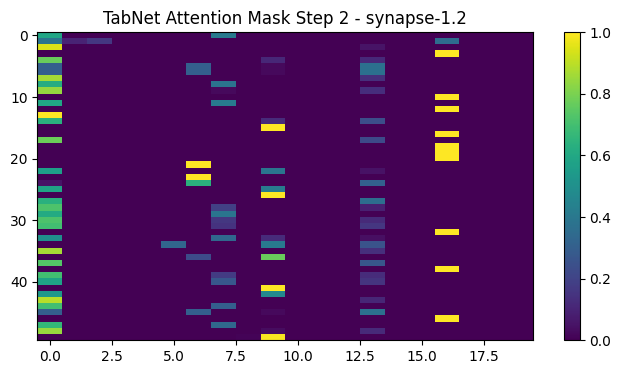

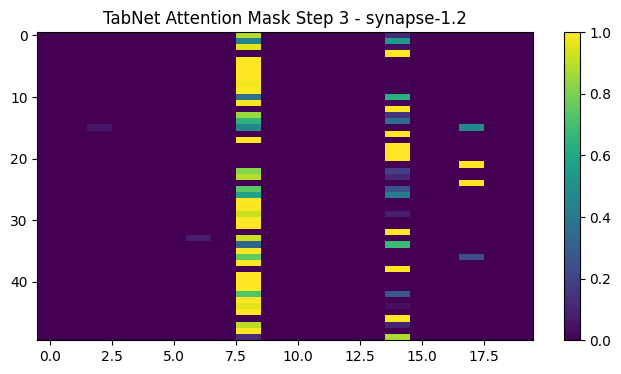

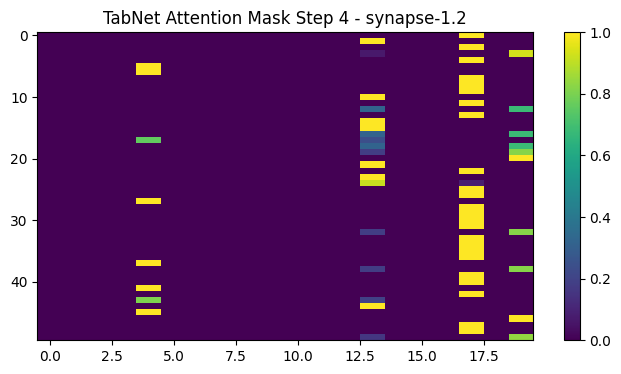

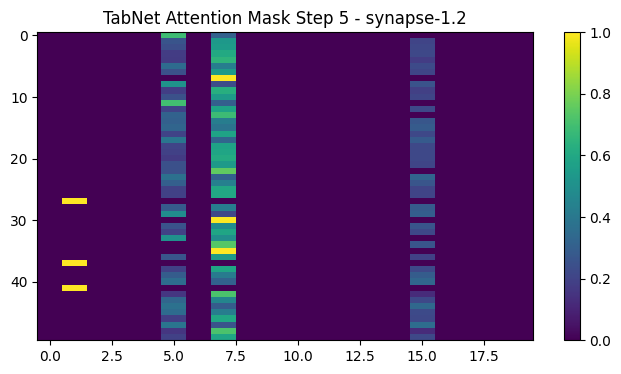

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/synapse-1.2_TabNet_LogisticRegression.png
Saved: results/roc_curves/synapse-1.2_TabNet_LogisticRegression.png
Training TabNet_RandomForest


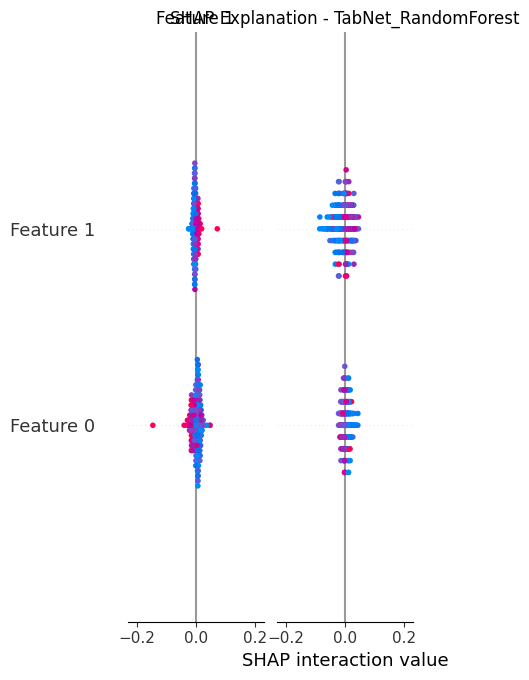

Saved: results/confusion_matrices/synapse-1.2_TabNet_RandomForest.png
Saved: results/roc_curves/synapse-1.2_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2514, number of negative: 2514
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3857
[LightGBM] [Info] Number of data points in the train set: 5028, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


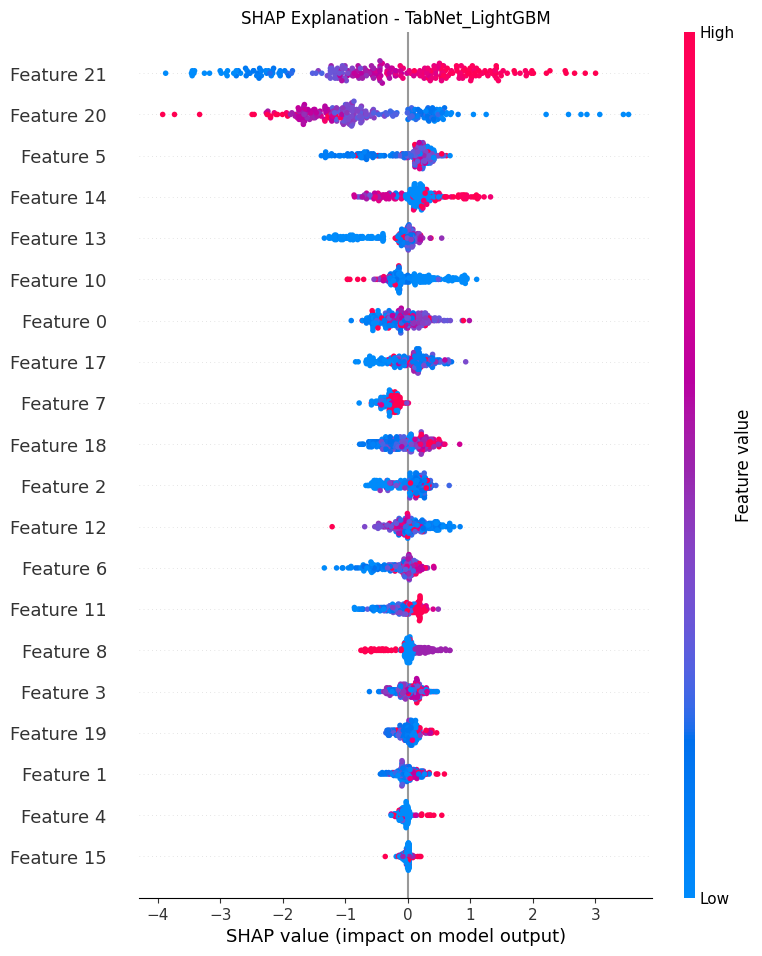

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/synapse-1.2_TabNet_LightGBM.png
Saved: results/roc_curves/synapse-1.2_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:01:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


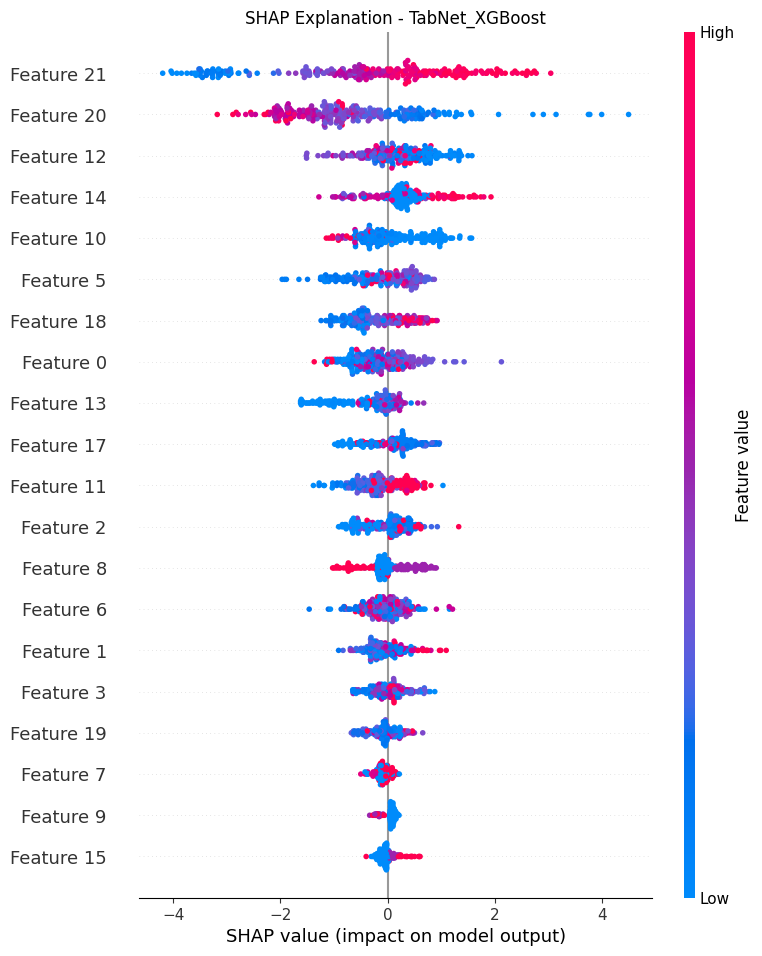

Saved: results/confusion_matrices/synapse-1.2_TabNet_XGBoost.png
Saved: results/roc_curves/synapse-1.2_TabNet_XGBoost.png

LOPO TABNET: camel-1.6


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.24122 |  0:00:00s
epoch 1  | loss: 0.74344 |  0:00:01s
epoch 2  | loss: 0.70682 |  0:00:01s
epoch 3  | loss: 0.75827 |  0:00:02s
epoch 4  | loss: 0.72699 |  0:00:03s
epoch 5  | loss: 0.67932 |  0:00:04s
epoch 6  | loss: 0.661   |  0:00:05s
epoch 7  | loss: 0.62699 |  0:00:05s
epoch 8  | loss: 0.60762 |  0:00:06s
epoch 9  | loss: 0.60268 |  0:00:07s
epoch 10 | loss: 0.58754 |  0:00:07s
epoch 11 | loss: 0.58096 |  0:00:08s
epoch 12 | loss: 0.57517 |  0:00:08s
epoch 13 | loss: 0.59143 |  0:00:09s
epoch 14 | loss: 0.58259 |  0:00:10s
epoch 15 | loss: 0.58261 |  0:00:10s
epoch 16 | loss: 0.57788 |  0:00:11s
epoch 17 | loss: 0.57333 |  0:00:11s
epoch 18 | loss: 0.57373 |  0:00:12s
epoch 19 | loss: 0.57277 |  0:00:12s
epoch 20 | loss: 0.5778  |  0:00:13s
epoch 21 | loss: 0.57506 |  0:00:13s
epoch 22 | loss: 0.56371 |  0:00:14s
epoch 23 | loss: 0.55888 |  0:00:15s
epoch 24 | loss: 0.54948 |  0:00:15s
epoch 25 | loss: 0.54453 |  0:00:16s
epoch 26 | loss: 0.54283 |  0:00:16s
e

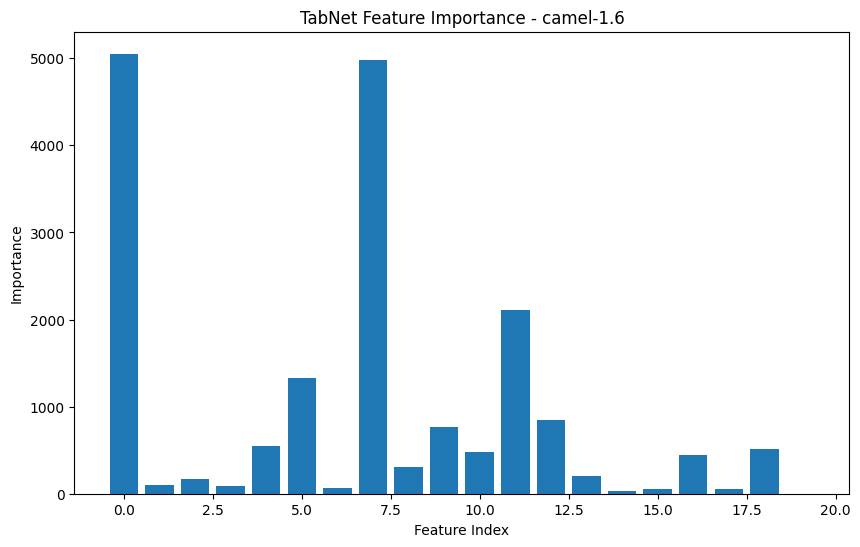

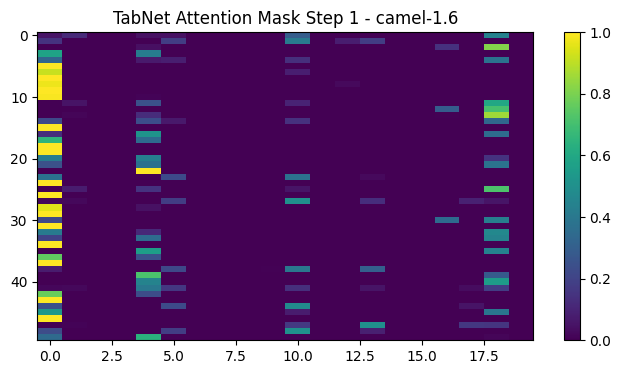

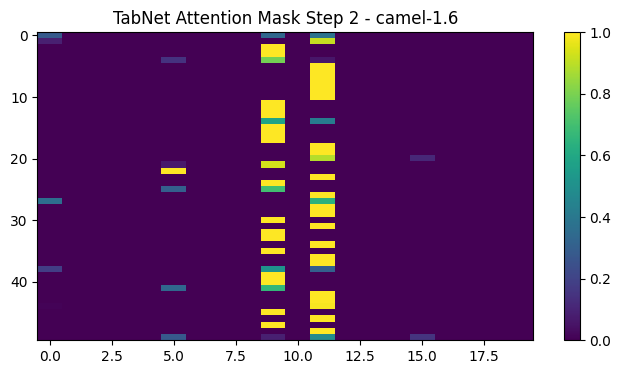

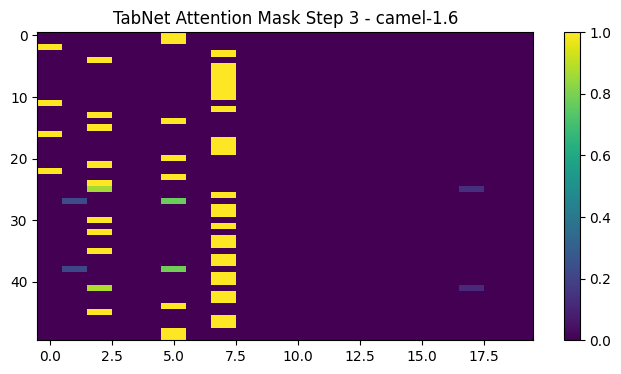

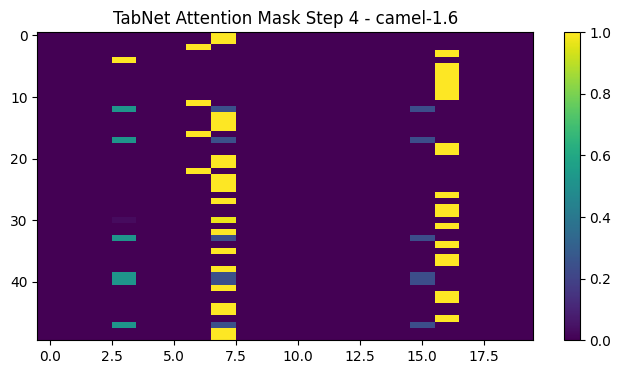

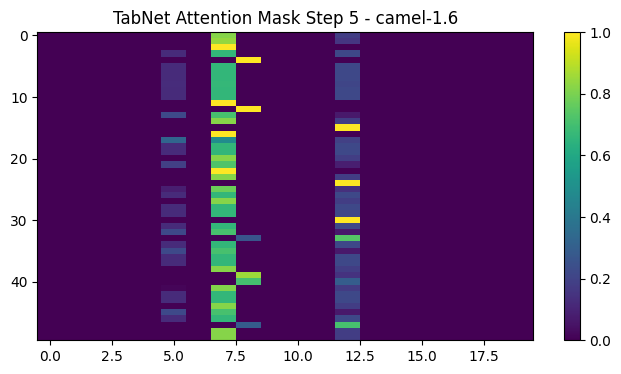

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/camel-1.6_TabNet_LogisticRegression.png
Saved: results/roc_curves/camel-1.6_TabNet_LogisticRegression.png
Training TabNet_RandomForest


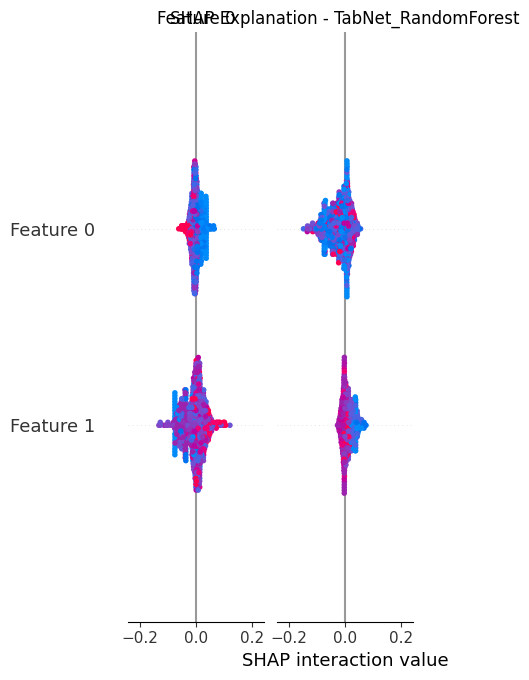

Saved: results/confusion_matrices/camel-1.6_TabNet_RandomForest.png
Saved: results/roc_curves/camel-1.6_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2412, number of negative: 2412
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4618
[LightGBM] [Info] Number of data points in the train set: 4824, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


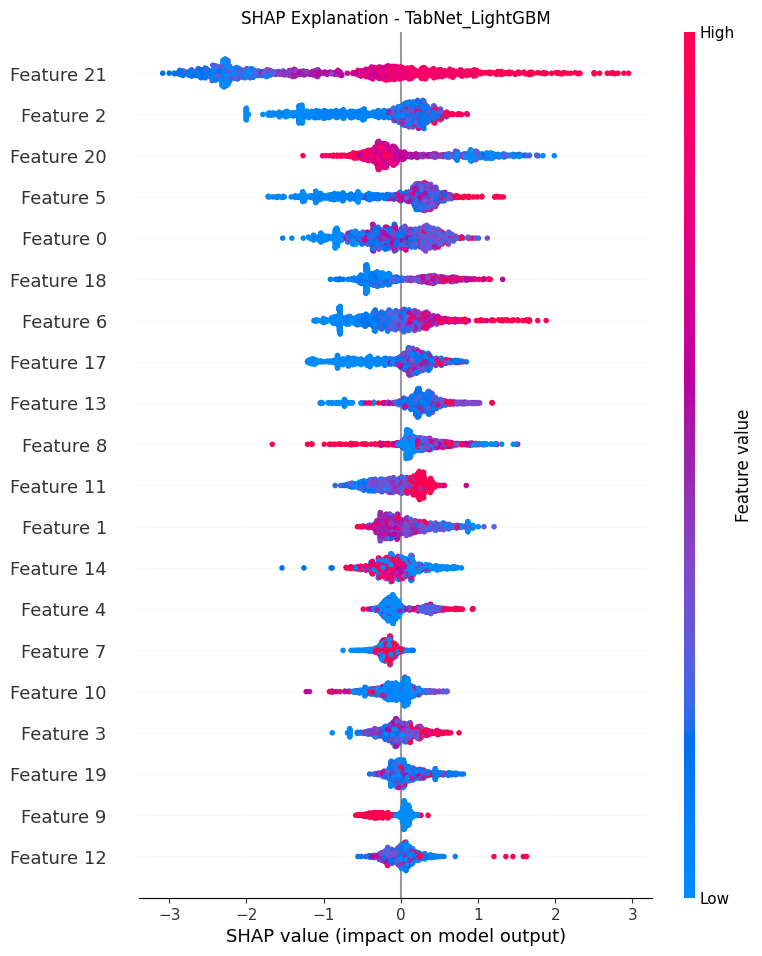

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/camel-1.6_TabNet_LightGBM.png
Saved: results/roc_curves/camel-1.6_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:04:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


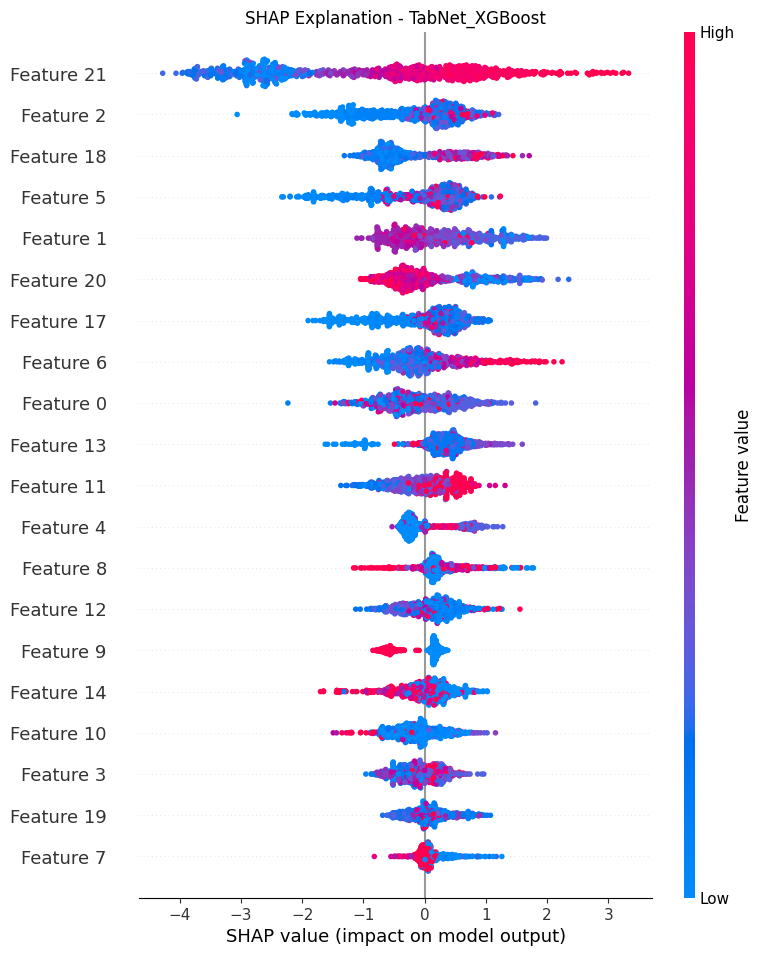

Saved: results/confusion_matrices/camel-1.6_TabNet_XGBoost.png
Saved: results/roc_curves/camel-1.6_TabNet_XGBoost.png

LOPO TABNET: poi-3.0


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.29662 |  0:00:00s
epoch 1  | loss: 0.91323 |  0:00:01s
epoch 2  | loss: 0.72926 |  0:00:01s
epoch 3  | loss: 0.6782  |  0:00:02s
epoch 4  | loss: 0.65907 |  0:00:02s
epoch 5  | loss: 0.638   |  0:00:03s
epoch 6  | loss: 0.60539 |  0:00:03s
epoch 7  | loss: 0.59853 |  0:00:04s
epoch 8  | loss: 0.59145 |  0:00:05s
epoch 9  | loss: 0.58387 |  0:00:06s
epoch 10 | loss: 0.5758  |  0:00:06s
epoch 11 | loss: 0.56365 |  0:00:07s
epoch 12 | loss: 0.5447  |  0:00:08s
epoch 13 | loss: 0.53767 |  0:00:08s
epoch 14 | loss: 0.52973 |  0:00:09s
epoch 15 | loss: 0.54326 |  0:00:10s
epoch 16 | loss: 0.53182 |  0:00:11s
epoch 17 | loss: 0.51921 |  0:00:11s
epoch 18 | loss: 0.52485 |  0:00:12s
epoch 19 | loss: 0.52474 |  0:00:13s
epoch 20 | loss: 0.51365 |  0:00:14s
epoch 21 | loss: 0.53051 |  0:00:14s
epoch 22 | loss: 0.52722 |  0:00:15s
epoch 23 | loss: 0.5285  |  0:00:16s
epoch 24 | loss: 0.51948 |  0:00:16s
epoch 25 | loss: 0.51352 |  0:00:17s
epoch 26 | loss: 0.51228 |  0:00:17s
e

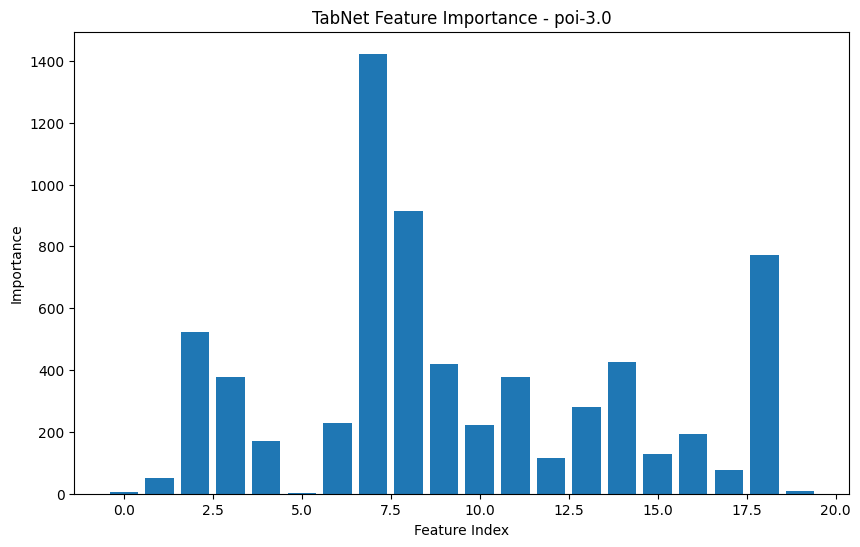

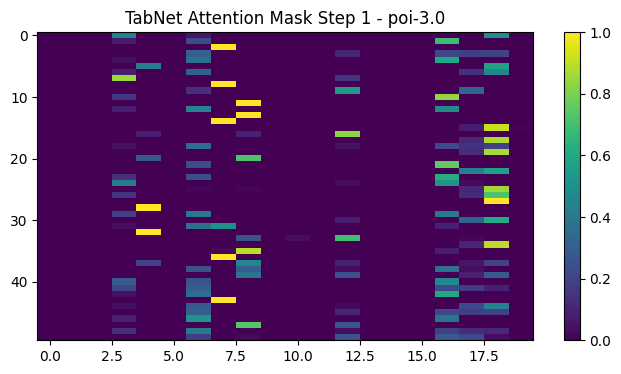

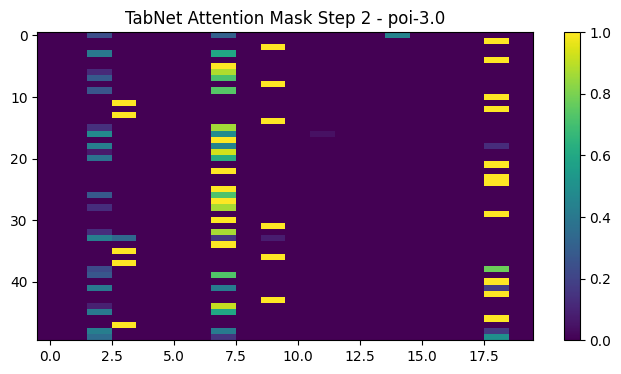

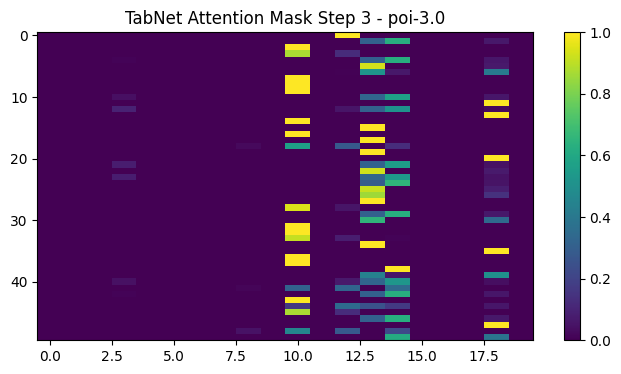

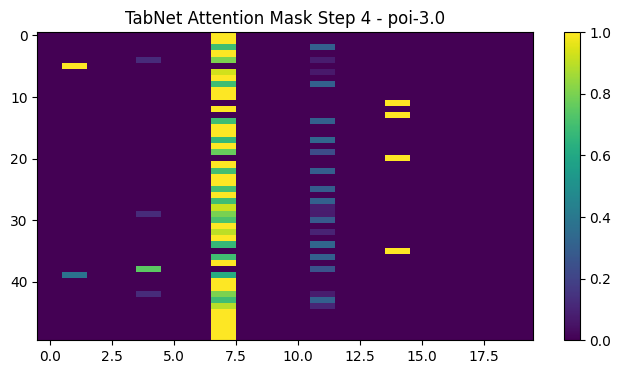

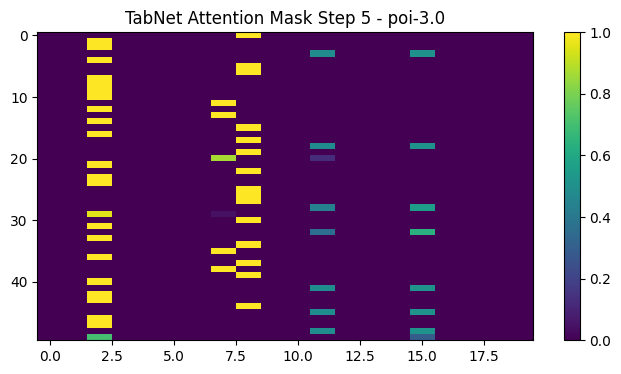

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/poi-3.0_TabNet_LogisticRegression.png
Saved: results/roc_curves/poi-3.0_TabNet_LogisticRegression.png
Training TabNet_RandomForest


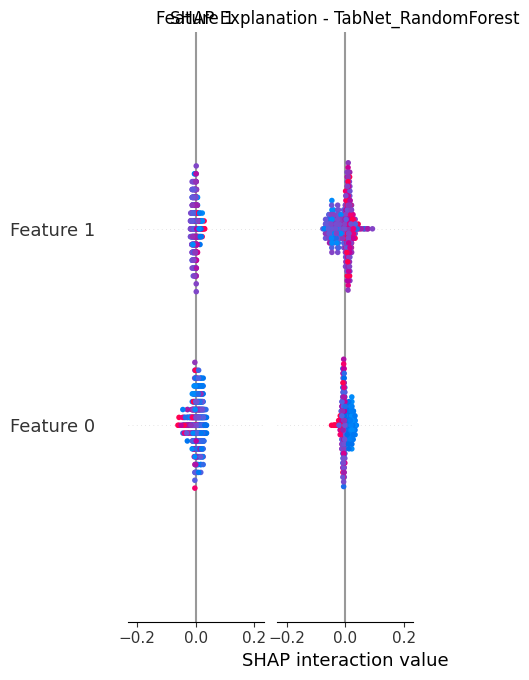

Saved: results/confusion_matrices/poi-3.0_TabNet_RandomForest.png
Saved: results/roc_curves/poi-3.0_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2521, number of negative: 2521
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4263
[LightGBM] [Info] Number of data points in the train set: 5042, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


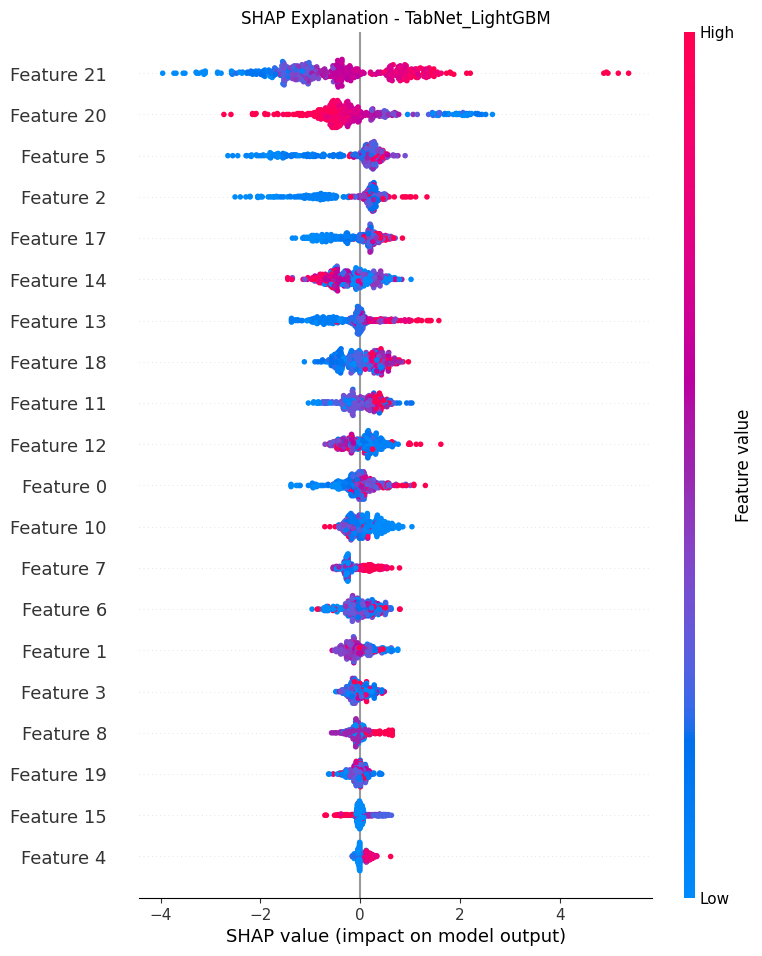

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/poi-3.0_TabNet_LightGBM.png
Saved: results/roc_curves/poi-3.0_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:06:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


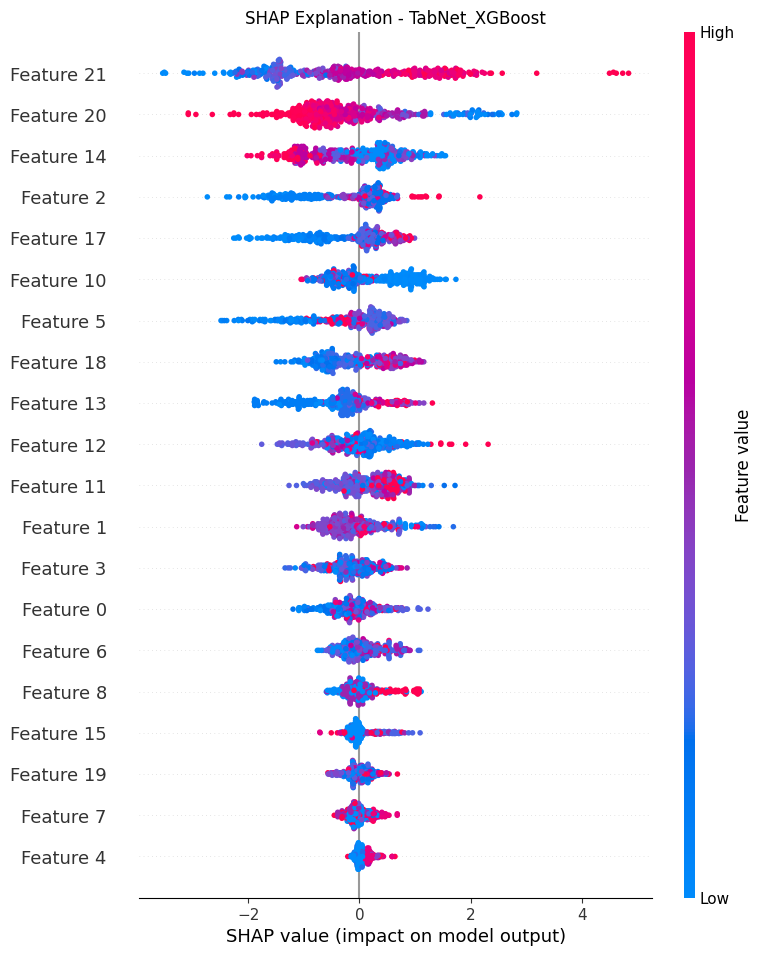

Saved: results/confusion_matrices/poi-3.0_TabNet_XGBoost.png
Saved: results/roc_curves/poi-3.0_TabNet_XGBoost.png

LOPO TABNET: jedit-4.3


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.25622 |  0:00:00s
epoch 1  | loss: 0.79558 |  0:00:01s
epoch 2  | loss: 0.72244 |  0:00:02s
epoch 3  | loss: 0.67249 |  0:00:03s
epoch 4  | loss: 0.66306 |  0:00:03s
epoch 5  | loss: 0.64369 |  0:00:04s
epoch 6  | loss: 0.63489 |  0:00:05s
epoch 7  | loss: 0.64488 |  0:00:05s
epoch 8  | loss: 0.61049 |  0:00:06s
epoch 9  | loss: 0.59427 |  0:00:06s
epoch 10 | loss: 0.56886 |  0:00:07s
epoch 11 | loss: 0.55289 |  0:00:08s
epoch 12 | loss: 0.54904 |  0:00:08s
epoch 13 | loss: 0.54974 |  0:00:09s
epoch 14 | loss: 0.53707 |  0:00:09s
epoch 15 | loss: 0.53661 |  0:00:10s
epoch 16 | loss: 0.53005 |  0:00:11s
epoch 17 | loss: 0.53156 |  0:00:11s
epoch 18 | loss: 0.5416  |  0:00:12s
epoch 19 | loss: 0.51952 |  0:00:12s
epoch 20 | loss: 0.52365 |  0:00:13s
epoch 21 | loss: 0.52131 |  0:00:14s
epoch 22 | loss: 0.52453 |  0:00:15s
epoch 23 | loss: 0.51924 |  0:00:15s
epoch 24 | loss: 0.51492 |  0:00:16s
epoch 25 | loss: 0.51883 |  0:00:17s
epoch 26 | loss: 0.52592 |  0:00:18s
e

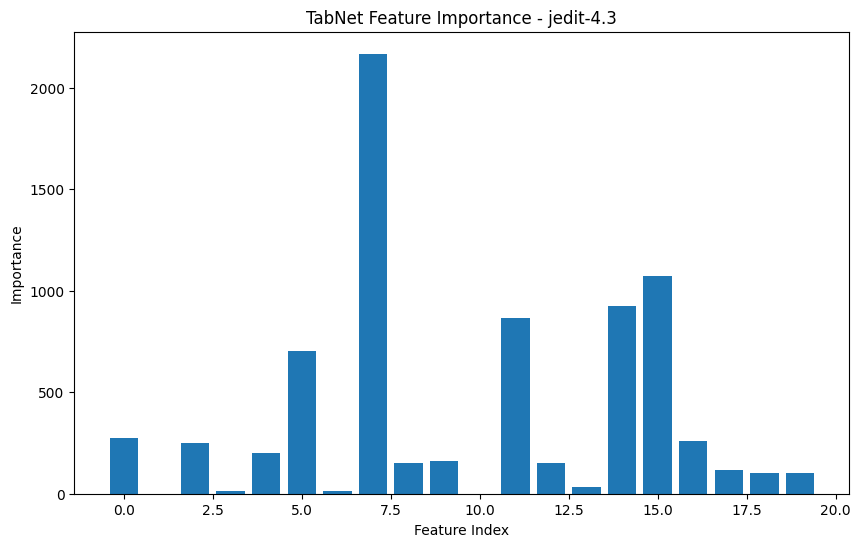

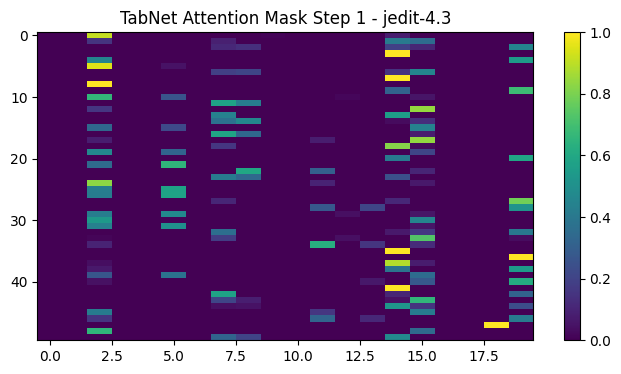

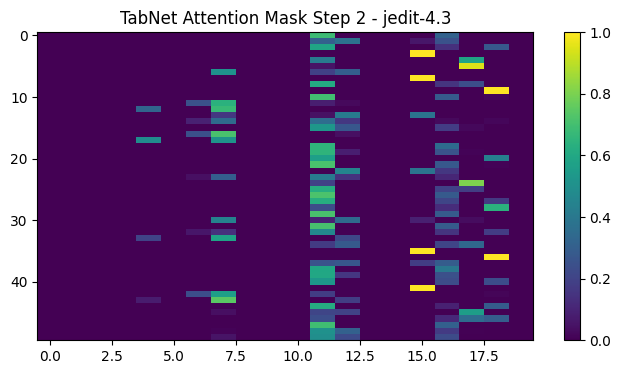

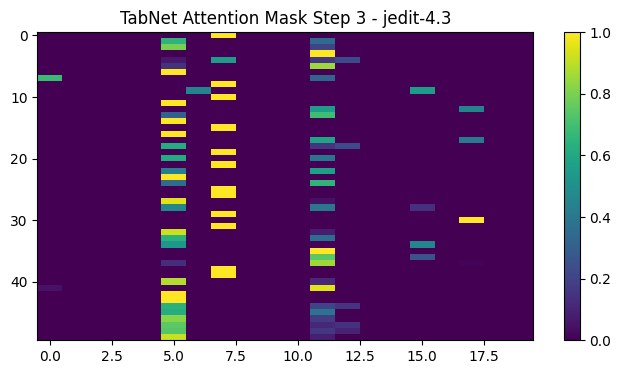

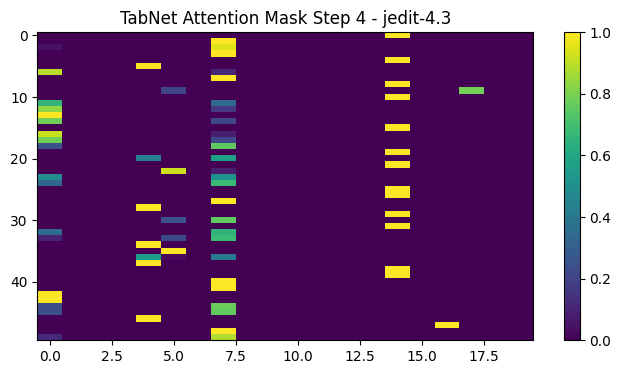

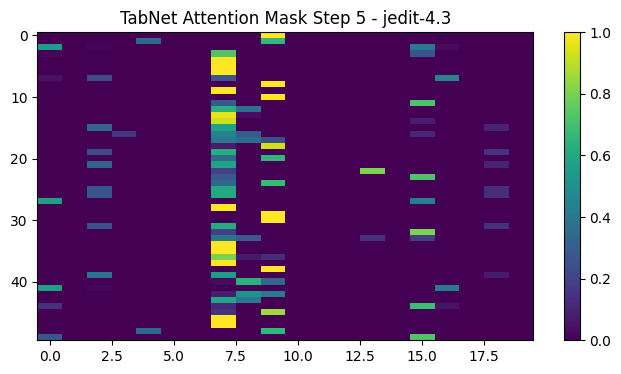

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/jedit-4.3_TabNet_LogisticRegression.png
Saved: results/roc_curves/jedit-4.3_TabNet_LogisticRegression.png
Training TabNet_RandomForest


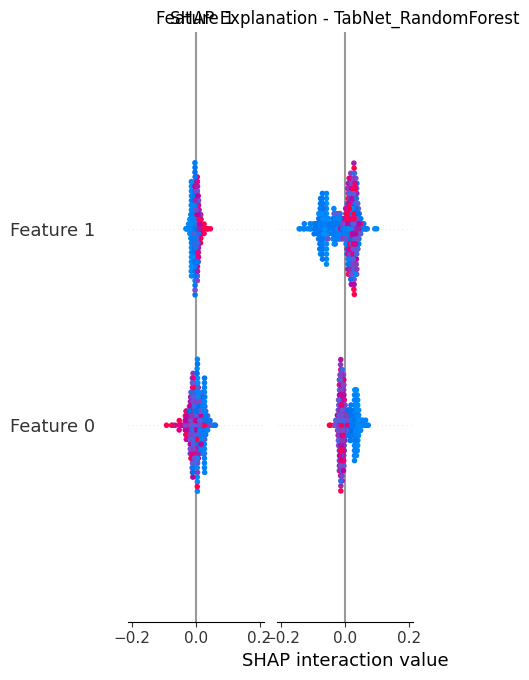

Saved: results/confusion_matrices/jedit-4.3_TabNet_RandomForest.png
Saved: results/roc_curves/jedit-4.3_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2589, number of negative: 2589
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002533 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4489
[LightGBM] [Info] Number of data points in the train set: 5178, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


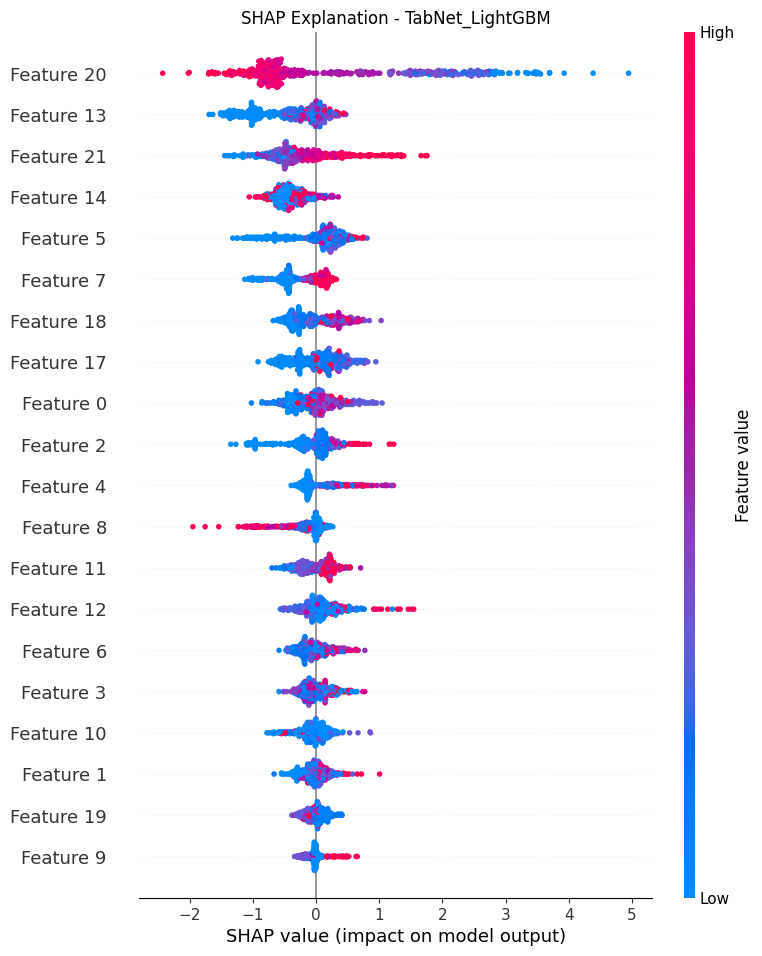

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/jedit-4.3_TabNet_LightGBM.png
Saved: results/roc_curves/jedit-4.3_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:09:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


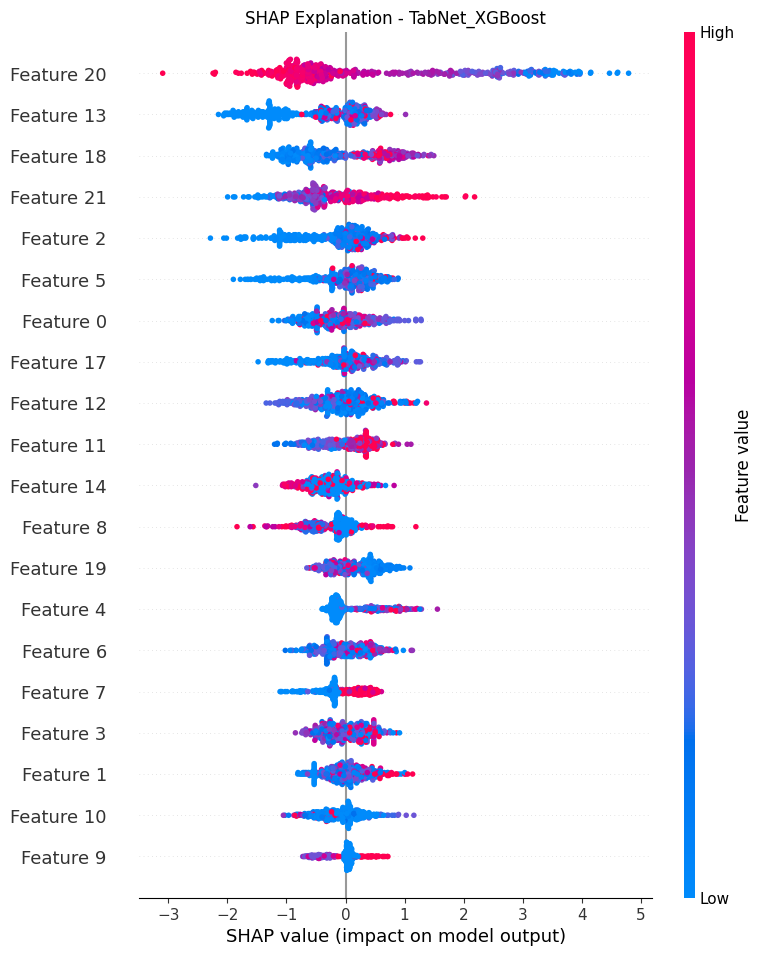

Saved: results/confusion_matrices/jedit-4.3_TabNet_XGBoost.png
Saved: results/roc_curves/jedit-4.3_TabNet_XGBoost.png

LOPO TABNET: velocity-1.6


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.35277 |  0:00:00s
epoch 1  | loss: 0.95824 |  0:00:01s
epoch 2  | loss: 0.77765 |  0:00:01s
epoch 3  | loss: 0.75471 |  0:00:02s
epoch 4  | loss: 0.67691 |  0:00:02s
epoch 5  | loss: 0.66256 |  0:00:03s
epoch 6  | loss: 0.62718 |  0:00:04s
epoch 7  | loss: 0.60444 |  0:00:05s
epoch 8  | loss: 0.59599 |  0:00:05s
epoch 9  | loss: 0.60294 |  0:00:06s
epoch 10 | loss: 0.58019 |  0:00:07s
epoch 11 | loss: 0.57249 |  0:00:08s
epoch 12 | loss: 0.55728 |  0:00:09s
epoch 13 | loss: 0.56694 |  0:00:09s
epoch 14 | loss: 0.54252 |  0:00:10s
epoch 15 | loss: 0.54294 |  0:00:11s
epoch 16 | loss: 0.54176 |  0:00:11s
epoch 17 | loss: 0.53662 |  0:00:12s
epoch 18 | loss: 0.53241 |  0:00:12s
epoch 19 | loss: 0.52237 |  0:00:13s
epoch 20 | loss: 0.52312 |  0:00:14s
epoch 21 | loss: 0.53395 |  0:00:14s
epoch 22 | loss: 0.52278 |  0:00:15s
epoch 23 | loss: 0.52149 |  0:00:15s
epoch 24 | loss: 0.51149 |  0:00:16s
epoch 25 | loss: 0.51183 |  0:00:17s
epoch 26 | loss: 0.49782 |  0:00:17s
e

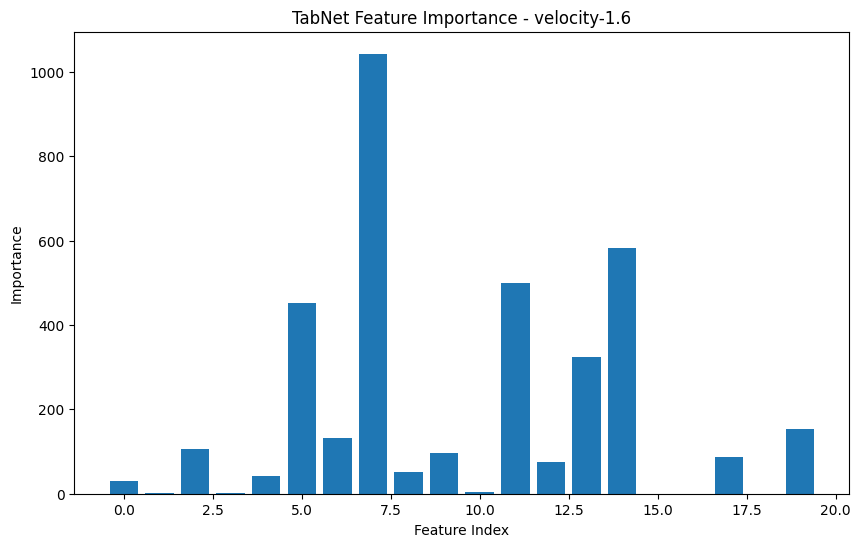

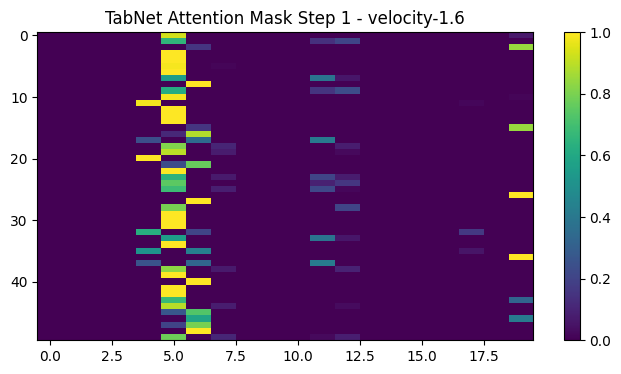

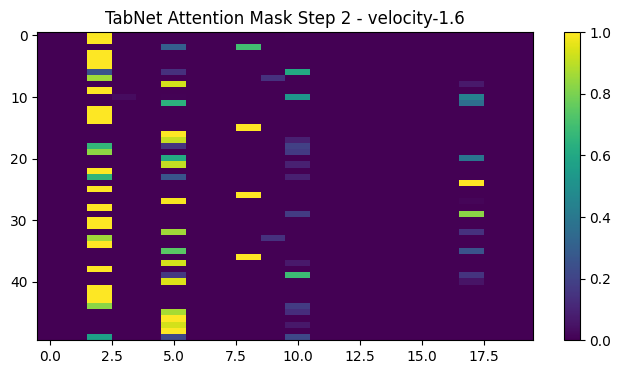

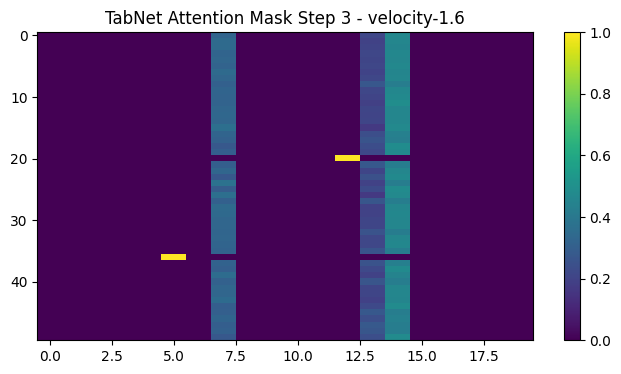

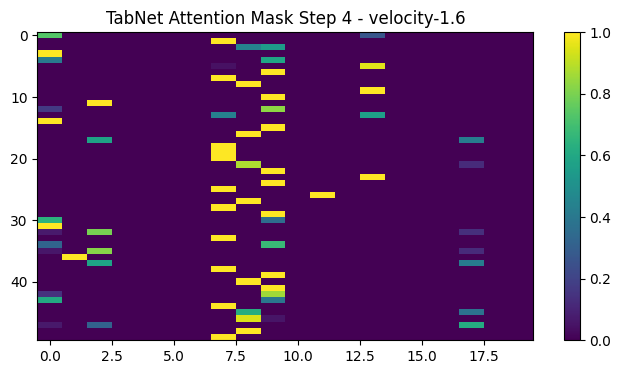

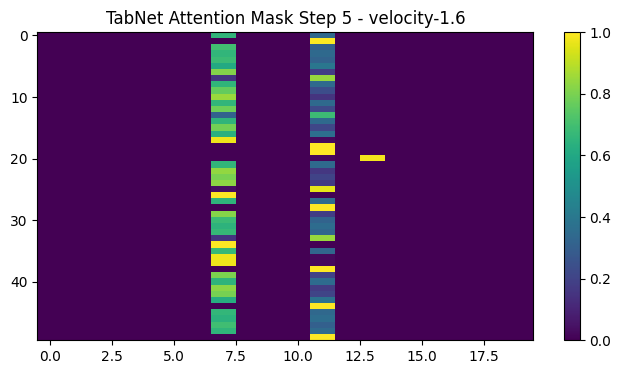

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/velocity-1.6_TabNet_LogisticRegression.png
Saved: results/roc_curves/velocity-1.6_TabNet_LogisticRegression.png
Training TabNet_RandomForest


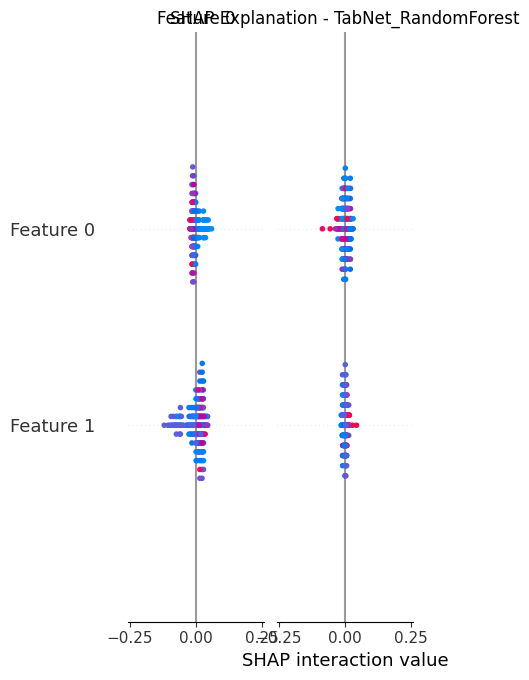

Saved: results/confusion_matrices/velocity-1.6_TabNet_RandomForest.png
Saved: results/roc_curves/velocity-1.6_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2531, number of negative: 2531
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3875
[LightGBM] [Info] Number of data points in the train set: 5062, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


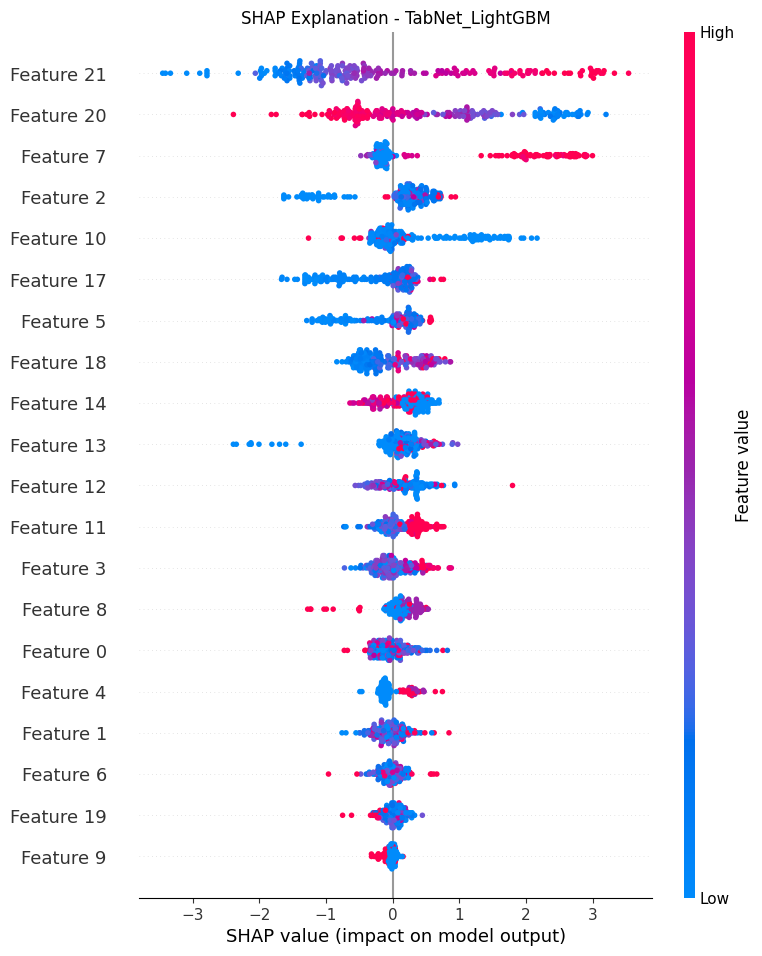

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/velocity-1.6_TabNet_LightGBM.png
Saved: results/roc_curves/velocity-1.6_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:11:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


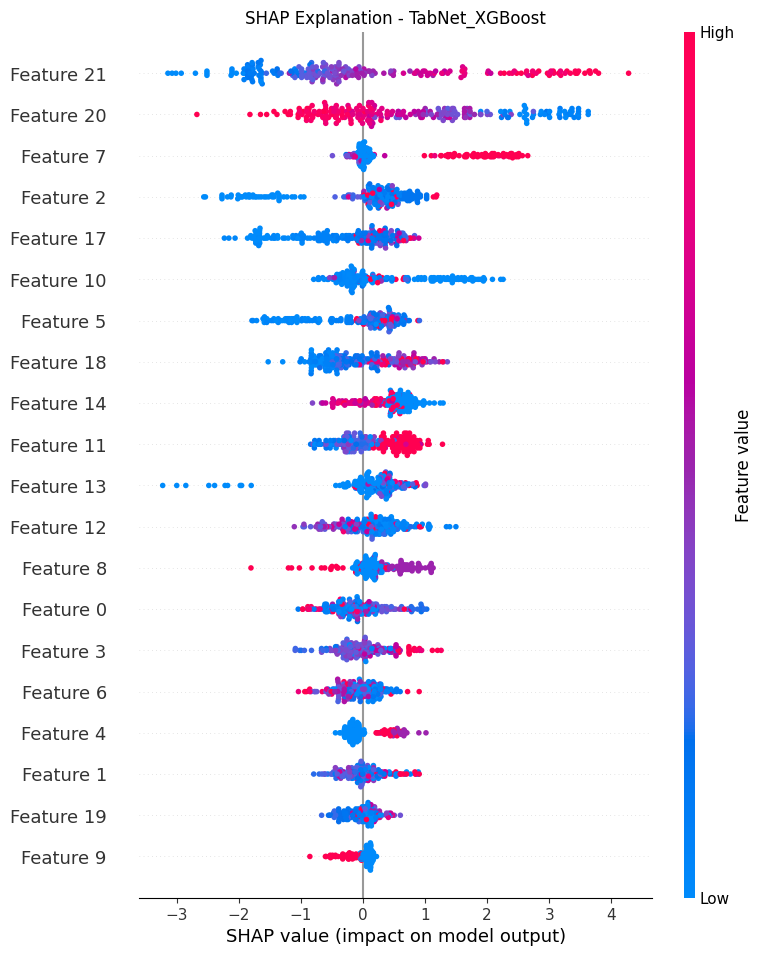

Saved: results/confusion_matrices/velocity-1.6_TabNet_XGBoost.png
Saved: results/roc_curves/velocity-1.6_TabNet_XGBoost.png

LOPO TABNET: ivy-1.0


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.19843 |  0:00:00s
epoch 1  | loss: 0.91996 |  0:00:01s
epoch 2  | loss: 0.79136 |  0:00:02s
epoch 3  | loss: 0.70196 |  0:00:02s
epoch 4  | loss: 0.66683 |  0:00:03s
epoch 5  | loss: 0.63847 |  0:00:04s
epoch 6  | loss: 0.62661 |  0:00:05s
epoch 7  | loss: 0.61585 |  0:00:05s
epoch 8  | loss: 0.60641 |  0:00:06s
epoch 9  | loss: 0.60854 |  0:00:07s
epoch 10 | loss: 0.58599 |  0:00:08s
epoch 11 | loss: 0.5788  |  0:00:08s
epoch 12 | loss: 0.58955 |  0:00:09s
epoch 13 | loss: 0.58711 |  0:00:10s
epoch 14 | loss: 0.5824  |  0:00:11s
epoch 15 | loss: 0.57237 |  0:00:12s
epoch 16 | loss: 0.5824  |  0:00:13s
epoch 17 | loss: 0.58021 |  0:00:14s
epoch 18 | loss: 0.55972 |  0:00:15s
epoch 19 | loss: 0.5563  |  0:00:16s
epoch 20 | loss: 0.55521 |  0:00:17s
epoch 21 | loss: 0.56251 |  0:00:18s
epoch 22 | loss: 0.54949 |  0:00:18s
epoch 23 | loss: 0.54272 |  0:00:19s
epoch 24 | loss: 0.54706 |  0:00:20s
epoch 25 | loss: 0.54621 |  0:00:20s
epoch 26 | loss: 0.5454  |  0:00:21s
e

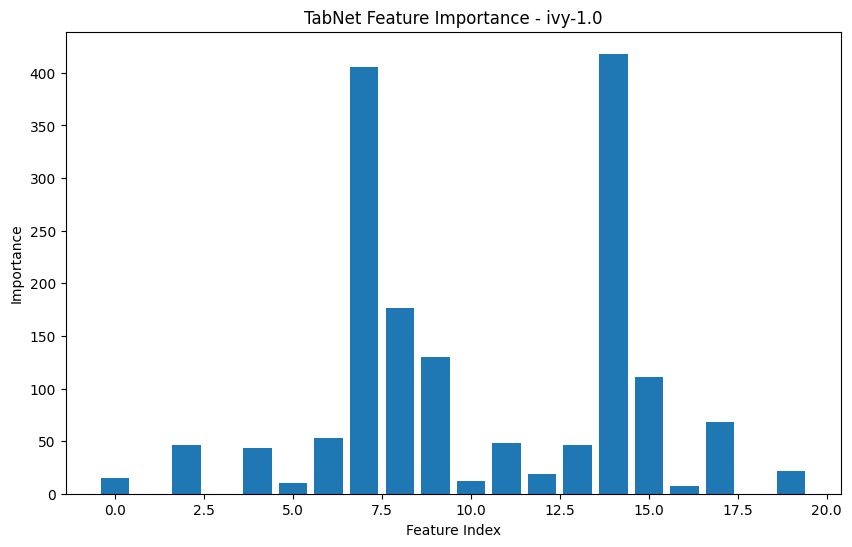

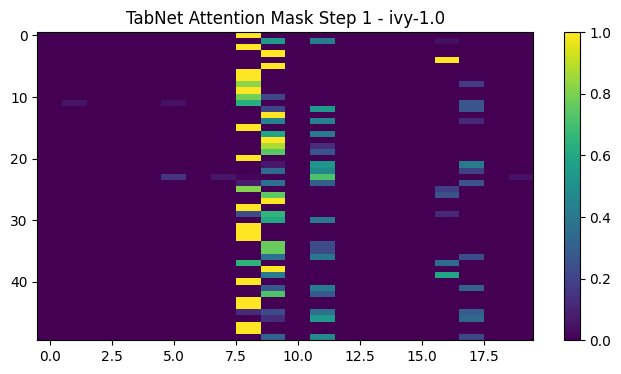

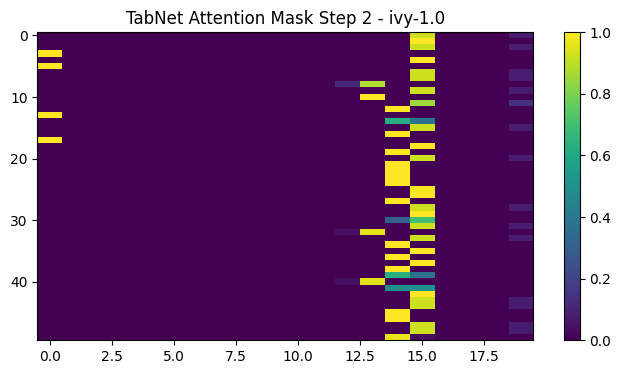

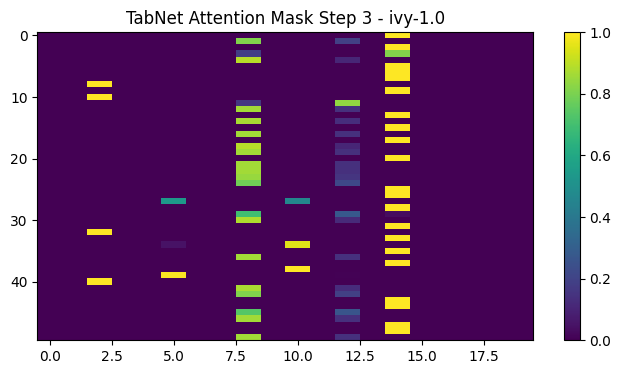

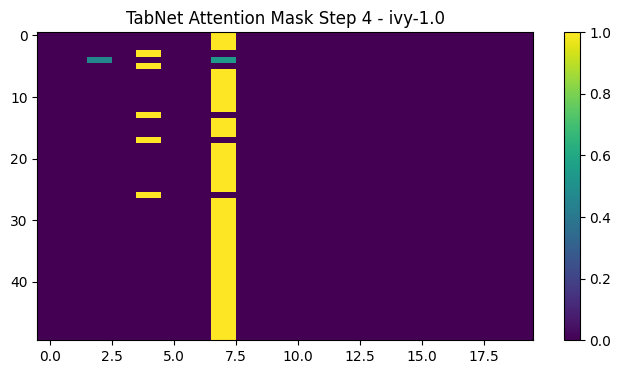

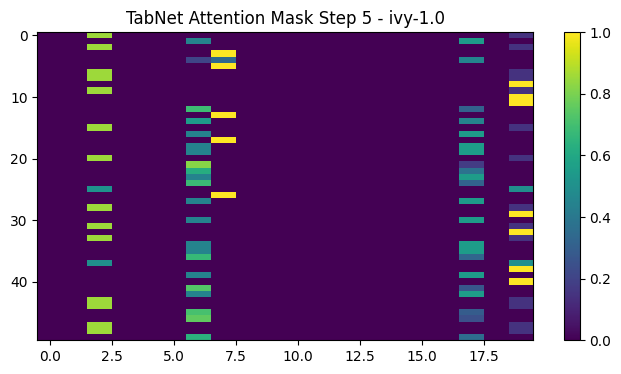

Training TabNet_LogisticRegression
Saved: results/confusion_matrices/ivy-1.0_TabNet_LogisticRegression.png
Saved: results/roc_curves/ivy-1.0_TabNet_LogisticRegression.png
Training TabNet_RandomForest


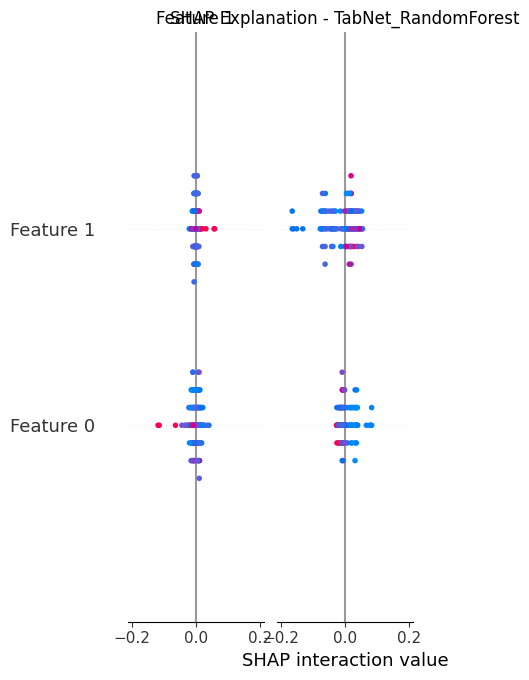

Saved: results/confusion_matrices/ivy-1.0_TabNet_RandomForest.png
Saved: results/roc_curves/ivy-1.0_TabNet_RandomForest.png
Training TabNet_LightGBM
[LightGBM] [Info] Number of positive: 2634, number of negative: 2634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4013
[LightGBM] [Info] Number of data points in the train set: 5268, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


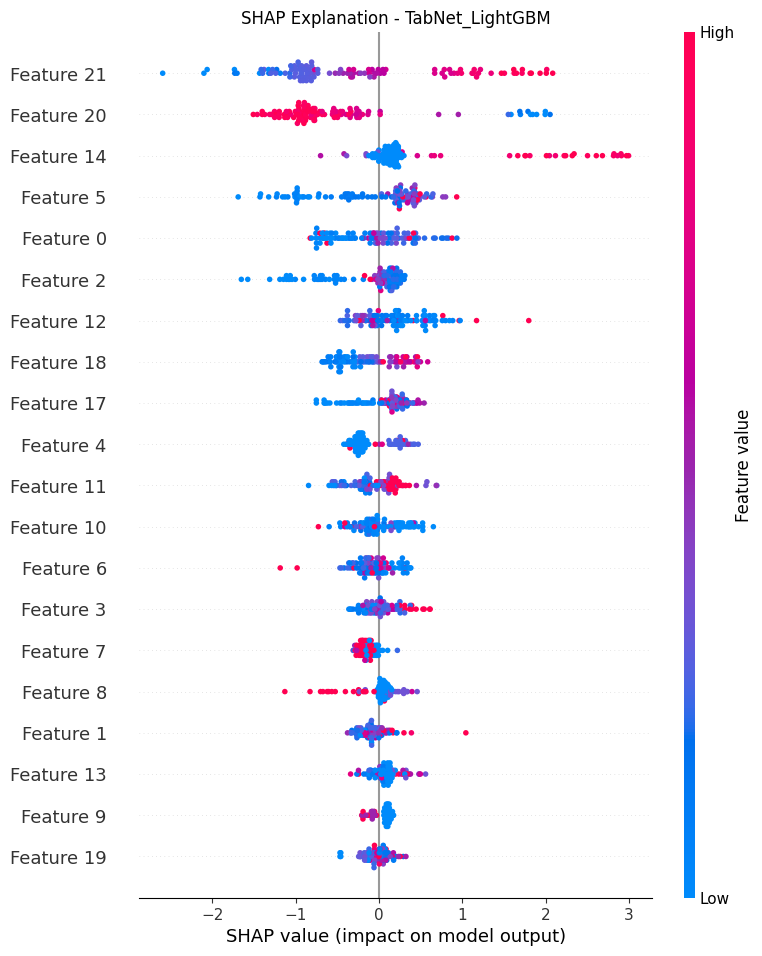

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/ivy-1.0_TabNet_LightGBM.png
Saved: results/roc_curves/ivy-1.0_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:13:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


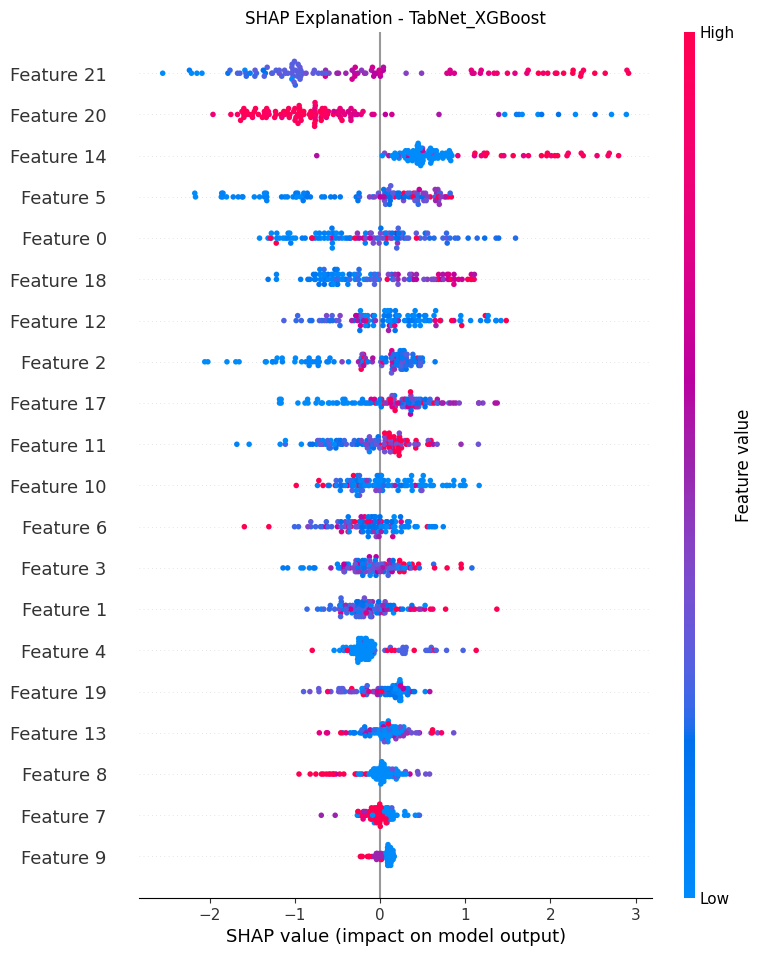

Saved: results/confusion_matrices/ivy-1.0_TabNet_XGBoost.png
Saved: results/roc_curves/ivy-1.0_TabNet_XGBoost.png
         project                      model  Accuracy        F1       MCC  \
0     lucene-2.4  TabNet_LogisticRegression  0.567647  0.624041  0.117627   
1     lucene-2.4        TabNet_RandomForest  0.617647  0.656085  0.234138   
2     lucene-2.4            TabNet_LightGBM  0.650000  0.713253  0.265148   
3     lucene-2.4             TabNet_XGBoost  0.670588  0.729469  0.309195   
4   xerces-1.4.4  TabNet_LogisticRegression  0.579932  0.648649  0.237060   
5   xerces-1.4.4        TabNet_RandomForest  0.581633  0.640351  0.279445   
6   xerces-1.4.4            TabNet_LightGBM  0.629252  0.704607  0.282685   
7   xerces-1.4.4             TabNet_XGBoost  0.607143  0.701935  0.163783   
8      log4j-1.2  TabNet_LogisticRegression  0.595122  0.734824  0.025221   
9      log4j-1.2        TabNet_RandomForest  0.580488  0.717105  0.109036   
10     log4j-1.2            TabNet_Ligh

In [57]:
# more embeddings and increased epoch.
import torch

tabnet_results_embed = []

for test_project in projects:

    print("\n==============================")
    print("LOPO TABNET:", test_project)
    print("==============================")

    train_projects = [p for p in projects if p != test_project]

    train_dfs = [normalized_projects[p] for p in train_projects]

    test_df = normalized_projects[test_project]

    aligned_train, aligned_test = align_features(train_dfs, test_df)

    train_df = pd.concat(aligned_train)

    X_train, y_train = extract_X_y(train_df)
    X_test, y_test = extract_X_y(aligned_test)

    selector = VarianceThreshold(0)

    X_train = selector.fit_transform(X_train)
    X_test = selector.transform(X_test)

    # --------------------------------
    # TabNet Training
    # --------------------------------

    tabnet = TabNetClassifier(
        n_d=32,
        n_a=32,
        n_steps=5,
        seed=42
    )

    tabnet.fit(
        X_train,
        y_train,
        max_epochs=100,
        patience=10
    )

    # --------------------------------
    # XAI: TabNet Feature Importance
    # --------------------------------

    explain_matrix, masks = tabnet.explain(X_test)

    feature_importance = np.sum(explain_matrix, axis=0)

    plt.figure(figsize=(10,6))
    plt.bar(range(len(feature_importance)), feature_importance)

    plt.title(f"TabNet Feature Importance - {test_project}")
    plt.xlabel("Feature Index")
    plt.ylabel("Importance")

    plt.show()

    # --------------------------------
    # XAI: TabNet Attention Masks
    # --------------------------------

    for step in range(len(masks)):

        plt.figure(figsize=(8,4))

        plt.imshow(masks[step][:50], aspect="auto")

        plt.title(f"TabNet Attention Mask Step {step+1} - {test_project}")

        plt.colorbar()

        plt.show()

    # --------------------------------
    # Extract TabNet embeddings
    # --------------------------------

    tabnet.network.eval()

    with torch.no_grad():

        train_tensor = torch.tensor(X_train, dtype=torch.float32)
        test_tensor = torch.tensor(X_test, dtype=torch.float32)

        train_emb = tabnet.network(train_tensor)[0].cpu().numpy()
        test_emb = tabnet.network(test_tensor)[0].cpu().numpy()

    # --------------------------------
    # Feature enrichment
    # --------------------------------

    X_train = np.hstack([X_train, train_emb])
    X_test = np.hstack([X_test, test_emb])

    # --------------------------------
    # SMOTE
    # --------------------------------

    smote = SMOTE(random_state=42)

    X_train, y_train = smote.fit_resample(X_train, y_train)

    # --------------------------------
    # Traditional Models
    # --------------------------------

    models = get_classifiers()

    for name, clf in models.items():

        model_name = "TabNet_" + name

        print("Training", model_name)

        clf.fit(X_train, y_train)
        import shap

        try:
            explainer = shap.TreeExplainer(clf)

            shap_values = explainer.shap_values(X_test)

            shap.summary_plot(
                shap_values,
                X_test,
                show=False
            )

            plt.title(f"SHAP Explanation - {model_name}")
            plt.show()

        except:
            pass

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, y_pred, y_prob)

        save_confusion_matrix(y_test, y_pred, model_name, test_project)
        save_roc_curve(y_test, y_prob, model_name, test_project)

        tabnet_results_embed.append({
            "project": test_project,
            "model": model_name,
            **metrics
        })

# --------------------------------
# Convert results to DataFrame
# --------------------------------

tabnet_embeddings_edited = pd.DataFrame(tabnet_results_embed)

print(tabnet_embeddings_edited)

In [25]:
tabnet_embeddings_edited = pd.DataFrame(tabnet_results_embed)
print(tabnet_embeddings_edited)

         project                      model  Accuracy        F1       MCC  \
0     lucene-2.4  TabNet_LogisticRegression  0.567647  0.624041  0.117627   
1     lucene-2.4        TabNet_RandomForest  0.617647  0.656085  0.234138   
2     lucene-2.4            TabNet_LightGBM  0.650000  0.713253  0.265148   
3     lucene-2.4             TabNet_XGBoost  0.670588  0.729469  0.309195   
4   xerces-1.4.4  TabNet_LogisticRegression  0.579932  0.648649  0.237060   
5   xerces-1.4.4        TabNet_RandomForest  0.581633  0.640351  0.279445   
6   xerces-1.4.4            TabNet_LightGBM  0.629252  0.704607  0.282685   
7   xerces-1.4.4             TabNet_XGBoost  0.607143  0.701935  0.163783   
8      log4j-1.2  TabNet_LogisticRegression  0.595122  0.734824  0.025221   
9      log4j-1.2        TabNet_RandomForest  0.580488  0.717105  0.109036   
10     log4j-1.2            TabNet_LightGBM  0.639024  0.771605  0.020577   
11     log4j-1.2             TabNet_XGBoost  0.663415  0.788991  0.068650   

In [26]:
print(len(baseline_results))
print(len(tabnet_results_small_embed))
print(len(tabnet_results_embed))


44
44
44


In [30]:
tabnet_classifier_results = []

In [31]:
Tabnet_classifier_df = pd.DataFrame(tabnet_classifier_results)

Tabnet_classifier_df.to_csv("tabnet_classifier_results.csv", index=False)

print(Tabnet_classifier_df)

Empty DataFrame
Columns: []
Index: []


### ONLY EMBEDDINGS

In [32]:
import torch

tabnet_results = []

for test_project in projects:

    print("\n==============================")
    print("LOPO TABNET:", test_project)
    print("==============================")

    train_projects = [p for p in projects if p != test_project]

    train_dfs = [normalized_projects[p] for p in train_projects]

    test_df = normalized_projects[test_project]

    aligned_train, aligned_test = align_features(train_dfs, test_df)

    train_df = pd.concat(aligned_train)

    X_train, y_train = extract_X_y(train_df)
    X_test, y_test = extract_X_y(aligned_test)

    selector = VarianceThreshold(0)

    X_train = selector.fit_transform(X_train)
    X_test = selector.transform(X_test)

    tabnet = TabNetClassifier(
        n_d=32,
        n_a=32,
        n_steps=5,
        seed=42
    )

    tabnet.fit(
        X_train,
        y_train,
        max_epochs=50,
        patience=10
    )

    # -----------------------------
    # Extract embeddings
    # -----------------------------

    tabnet.network.eval()

    with torch.no_grad():

        train_tensor = torch.tensor(X_train, dtype=torch.float32)
        test_tensor = torch.tensor(X_test, dtype=torch.float32)

        train_emb = tabnet.network(train_tensor)[0].cpu().numpy()
        test_emb = tabnet.network(test_tensor)[0].cpu().numpy()

    # -----------------------------
    # REPLACE FEATURES
    # -----------------------------

    X_train = train_emb
    X_test = test_emb

    # -----------------------------
    # SMOTE
    # -----------------------------

    smote = SMOTE(random_state=42)

    X_train, y_train = smote.fit_resample(X_train, y_train)

    models = get_classifiers()

    for name, clf in models.items():

        model_name = "TabNet_" + name

        print("Training", model_name)

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, y_pred, y_prob)

        save_confusion_matrix(y_test, y_pred, model_name, test_project)
        save_roc_curve(y_test, y_prob, model_name, test_project)

        tabnet_results.append({
            "project": test_project,
            "model": model_name,
            **metrics
        })


LOPO TABNET: lucene-2.4


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 1.37281 |  0:00:00s
epoch 1  | loss: 0.92005 |  0:00:01s
epoch 2  | loss: 0.7875  |  0:00:01s
epoch 3  | loss: 0.76795 |  0:00:02s
epoch 4  | loss: 0.71777 |  0:00:02s
epoch 5  | loss: 0.69009 |  0:00:03s
epoch 6  | loss: 0.68102 |  0:00:03s
epoch 7  | loss: 0.66336 |  0:00:04s
epoch 8  | loss: 0.61731 |  0:00:04s
epoch 9  | loss: 0.61346 |  0:00:05s
epoch 10 | loss: 0.60289 |  0:00:05s
epoch 11 | loss: 0.58646 |  0:00:06s
epoch 12 | loss: 0.58631 |  0:00:06s
epoch 13 | loss: 0.5879  |  0:00:07s
epoch 14 | loss: 0.56602 |  0:00:07s
epoch 15 | loss: 0.55875 |  0:00:08s
epoch 16 | loss: 0.57183 |  0:00:08s
epoch 17 | loss: 0.55642 |  0:00:10s
epoch 18 | loss: 0.54349 |  0:00:10s
epoch 19 | loss: 0.53454 |  0:00:11s
epoch 20 | loss: 0.52548 |  0:00:12s
epoch 21 | loss: 0.53368 |  0:00:14s
epoch 22 | loss: 0.52266 |  0:00:16s
epoch 23 | loss: 0.51777 |  0:00:16s
epoch 24 | loss: 0.52245 |  0:00:17s
epoch 25 | loss: 0.51651 |  0:00:17s
epoch 26 | loss: 0.51789 |  0:00:18s
e

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/lucene-2.4_TabNet_LightGBM.png
Saved: results/roc_curves/lucene-2.4_TabNet_LightGBM.png
Training TabNet_XGBoost


...

epoch 0  | loss: 1.19843 |  0:00:00s
epoch 1  | loss: 0.91996 |  0:00:01s
epoch 2  | loss: 0.79136 |  0:00:02s
epoch 3  | loss: 0.70196 |  0:00:03s
epoch 4  | loss: 0.66683 |  0:00:04s
epoch 5  | loss: 0.63847 |  0:00:05s
epoch 6  | loss: 0.62661 |  0:00:06s
epoch 7  | loss: 0.61585 |  0:00:06s
epoch 8  | loss: 0.60641 |  0:00:07s
epoch 9  | loss: 0.60854 |  0:00:07s
epoch 10 | loss: 0.58599 |  0:00:08s
epoch 11 | loss: 0.5788  |  0:00:09s
epoch 12 | loss: 0.58955 |  0:00:09s
epoch 13 | loss: 0.58711 |  0:00:10s
epoch 14 | loss: 0.5824  |  0:00:11s
epoch 15 | loss: 0.57237 |  0:00:11s
epoch 16 | loss: 0.5824  |  0:00:12s
epoch 17 | loss: 0.58021 |  0:00:13s
epoch 18 | loss: 0.55972 |  0:00:13s
epoch 19 | loss: 0.5563  |  0:00:14s
epoch 20 | loss: 0.55521 |  0:00:14s
epoch 21 | loss: 0.56251 |  0:00:15s
epoch 22 | loss: 0.54949 |  0:00:16s
epoch 23 | loss: 0.54272 |  0:00:17s
epoch 24 | loss: 0.54706 |  0:00:18s
epoch 25 | loss: 0.54621 |  0:00:19s
epoch 26 | loss: 0.5454  |  0:00:20s
e

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved: results/confusion_matrices/ivy-1.0_TabNet_LightGBM.png
Saved: results/roc_curves/ivy-1.0_TabNet_LightGBM.png
Training TabNet_XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:29:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved: results/confusion_matrices/ivy-1.0_TabNet_XGBoost.png
Saved: results/roc_curves/ivy-1.0_TabNet_XGBoost.png


In [33]:
Tabnet_only_em = pd.DataFrame(tabnet_results)

#Tabnet_classifier_df.to_csv("tabnet_classifier_results.csv", index=False)

print(Tabnet_only_em)

         project                      model  Accuracy        F1       MCC  \
0     lucene-2.4  TabNet_LogisticRegression  0.582353  0.620321  0.166739   
1     lucene-2.4        TabNet_RandomForest  0.573529  0.615385  0.145295   
2     lucene-2.4            TabNet_LightGBM  0.567647  0.601626  0.142613   
3     lucene-2.4             TabNet_XGBoost  0.591176  0.637076  0.174551   
4   xerces-1.4.4  TabNet_LogisticRegression  0.559524  0.650472  0.117384   
5   xerces-1.4.4        TabNet_RandomForest  0.528912  0.611501  0.100450   
6   xerces-1.4.4            TabNet_LightGBM  0.542517  0.621660  0.135505   
7   xerces-1.4.4             TabNet_XGBoost  0.517007  0.603352  0.067419   
8      log4j-1.2  TabNet_LogisticRegression  0.580488  0.718954  0.078317   
9      log4j-1.2        TabNet_RandomForest  0.570732  0.710526  0.072393   
10     log4j-1.2            TabNet_LightGBM  0.560976  0.707792 -0.026245   
11     log4j-1.2             TabNet_XGBoost  0.580488  0.718954  0.078317   

In [34]:
results = pd.concat([
    baseline_df,
    Tabnet_only_em,
    Tabnet_classifier_df
])

print(results)

         project                      model  Accuracy        F1       MCC  \
0     lucene-2.4         LogisticRegression  0.594118  0.691964  0.116539   
1     lucene-2.4               RandomForest  0.664706  0.703125  0.323673   
2     lucene-2.4                   LightGBM  0.632353  0.720358  0.204048   
3     lucene-2.4                    XGBoost  0.676471  0.750000  0.306614   
4   xerces-1.4.4         LogisticRegression  0.508503  0.550544  0.195032   
..           ...                        ...       ...       ...       ...   
39  velocity-1.6             TabNet_XGBoost  0.371179  0.394958 -0.150574   
40       ivy-1.0  TabNet_LogisticRegression  0.558559  0.461538  0.213882   
41       ivy-1.0        TabNet_RandomForest  0.558559  0.505051  0.177433   
42       ivy-1.0            TabNet_LightGBM  0.594595  0.536082  0.264422   
43       ivy-1.0             TabNet_XGBoost  0.522523  0.442105  0.113928   

       GMean       AUC  
0   0.511807  0.646003  
1   0.664629  0.704433  


In [35]:
mean_results = results.groupby("model").mean(numeric_only=True)

print(mean_results.sort_values("MCC", ascending=False))

                           Accuracy        F1       MCC     GMean       AUC
model                                                                      
RandomForest               0.577302  0.505014  0.192131  0.599228  0.673160
XGBoost                    0.598536  0.548412  0.163976  0.587958  0.649108
LightGBM                   0.592621  0.548470  0.157346  0.581273  0.650656
LogisticRegression         0.568863  0.449510  0.129122  0.532479  0.625481
TabNet_LogisticRegression  0.559127  0.491913  0.091990  0.521429  0.585361
TabNet_LightGBM            0.540625  0.482667  0.081975  0.532958  0.569743
TabNet_RandomForest        0.533970  0.476429  0.073267  0.534202  0.583677
TabNet_XGBoost             0.535225  0.472681  0.063425  0.518414  0.563842


In [36]:
metrics = ["Accuracy", "F1", "MCC", "GMean", "AUC"]

pivot_tables = {
    metric: results.pivot(index="project", columns="model", values=metric)
    for metric in metrics
}

print(pivot_tables["Accuracy"])

model         LightGBM  LogisticRegression  RandomForest  TabNet_LightGBM  \
project                                                                     
ant-1.7       0.491275            0.672483      0.565101         0.598658   
camel-1.6     0.589637            0.703627      0.643523         0.606218   
ivy-1.0       0.522523            0.486486      0.603604         0.594595   
jedit-4.3     0.621951            0.479675      0.591463         0.408537   
log4j-1.2     0.692683            0.595122      0.512195         0.560976   
lucene-2.4    0.632353            0.594118      0.664706         0.567647   
poi-3.0       0.601810            0.477376      0.574661         0.497738   
synapse-1.2   0.671875            0.710938      0.644531         0.593750   
velocity-1.6  0.458515            0.497817      0.454148         0.371179   
xalan-2.7     0.617162            0.531353      0.499450         0.605061   
xerces-1.4.4  0.619048            0.508503      0.596939         0.542517   

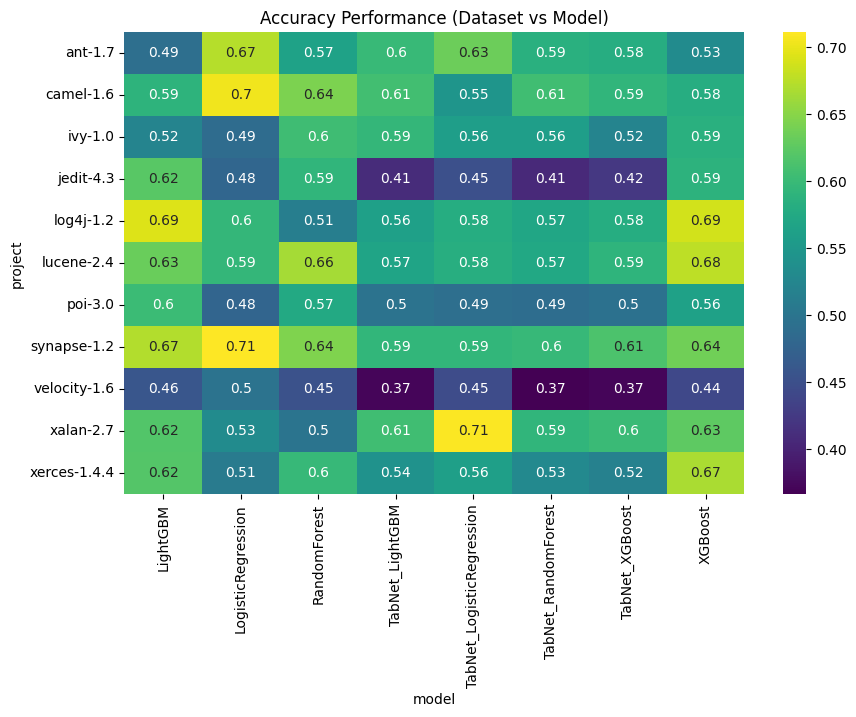

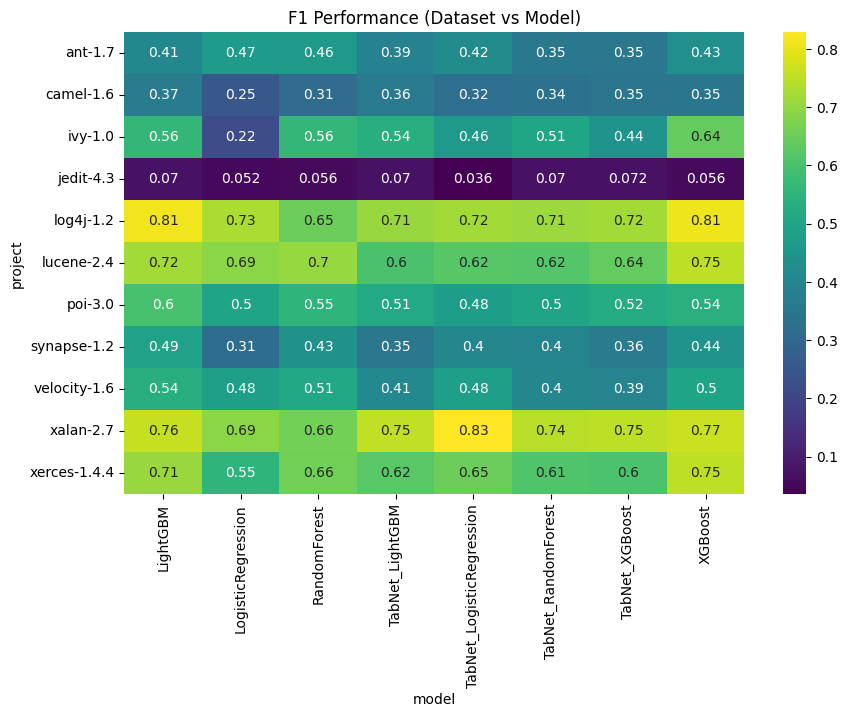

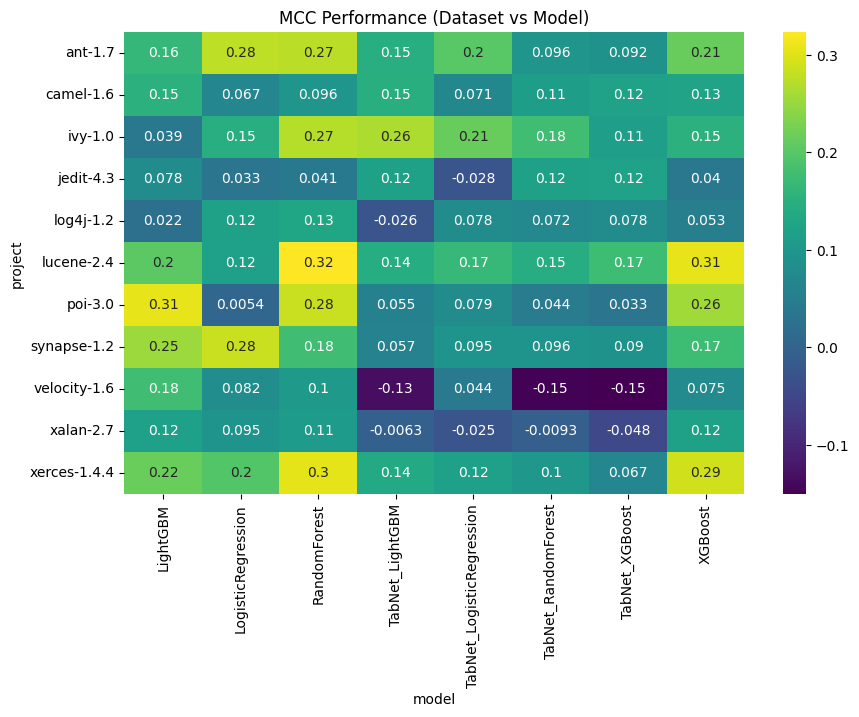

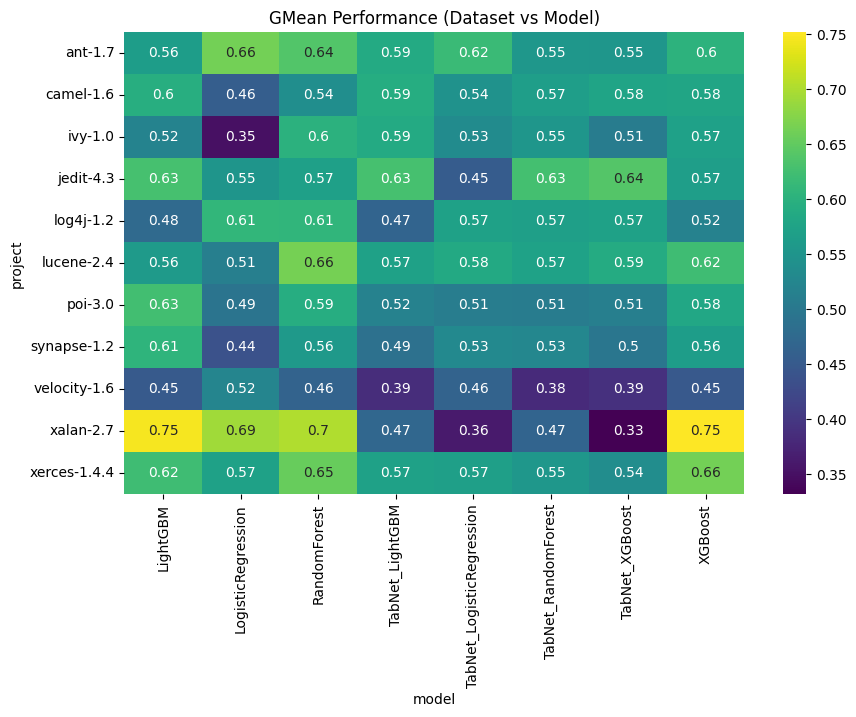

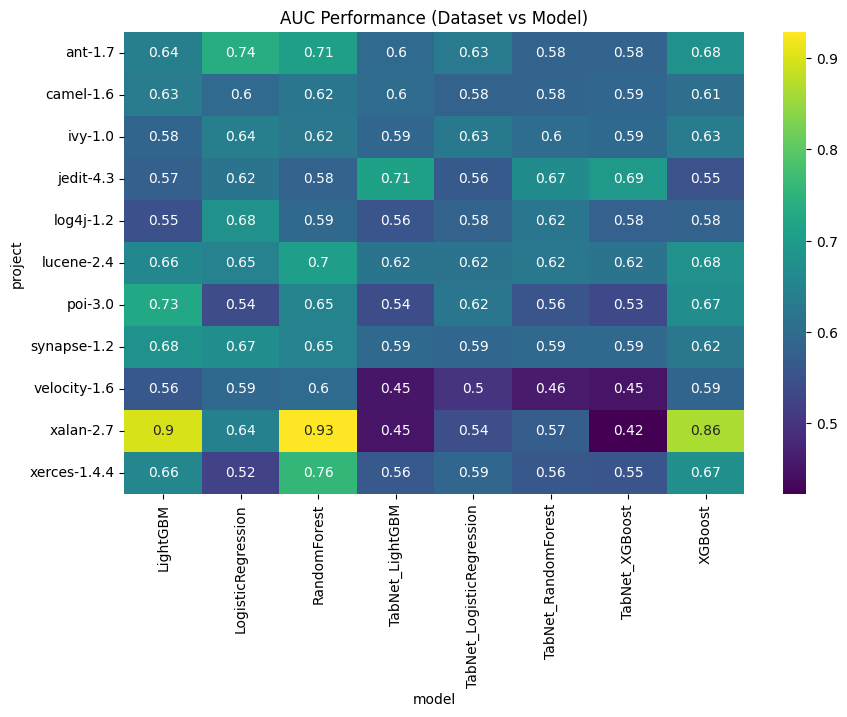

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

for metric in metrics:

    plt.figure(figsize=(10,6))

    sns.heatmap(
        pivot_tables[metric],
        annot=True,
        cmap="viridis"
    )

    plt.title(f"{metric} Performance (Dataset vs Model)")

    plt.show()

In [38]:
for metric in metrics:

    print("\nAverage", metric)

    display(
       print( pivot_tables[metric]
        .mean()
        .sort_values(ascending=False))
    )


Average Accuracy
model
XGBoost                      0.598536
LightGBM                     0.592621
RandomForest                 0.577302
LogisticRegression           0.568863
TabNet_LogisticRegression    0.559127
TabNet_LightGBM              0.540625
TabNet_XGBoost               0.535225
TabNet_RandomForest          0.533970
dtype: float64


None


Average F1
model
LightGBM                     0.548470
XGBoost                      0.548412
RandomForest                 0.505014
TabNet_LogisticRegression    0.491913
TabNet_LightGBM              0.482667
TabNet_RandomForest          0.476429
TabNet_XGBoost               0.472681
LogisticRegression           0.449510
dtype: float64


None


Average MCC
model
RandomForest                 0.192131
XGBoost                      0.163976
LightGBM                     0.157346
LogisticRegression           0.129122
TabNet_LogisticRegression    0.091990
TabNet_LightGBM              0.081975
TabNet_RandomForest          0.073267
TabNet_XGBoost               0.063425
dtype: float64


None


Average GMean
model
RandomForest                 0.599228
XGBoost                      0.587958
LightGBM                     0.581273
TabNet_RandomForest          0.534202
TabNet_LightGBM              0.532958
LogisticRegression           0.532479
TabNet_LogisticRegression    0.521429
TabNet_XGBoost               0.518414
dtype: float64


None


Average AUC
model
RandomForest                 0.673160
LightGBM                     0.650656
XGBoost                      0.649108
LogisticRegression           0.625481
TabNet_LogisticRegression    0.585361
TabNet_RandomForest          0.583677
TabNet_LightGBM              0.569743
TabNet_XGBoost               0.563842
dtype: float64


None

In [39]:
for metric in metrics:

    winners = pivot_tables[metric].idxmax(axis=1)

    print("\nWins for", metric)

    print(winners.value_counts())


Wins for Accuracy
LogisticRegression           4
LightGBM                     3
XGBoost                      2
RandomForest                 1
TabNet_LogisticRegression    1
Name: count, dtype: int64

Wins for F1
LightGBM                     5
XGBoost                      3
LogisticRegression           1
TabNet_XGBoost               1
TabNet_LogisticRegression    1
Name: count, dtype: int64

Wins for MCC
RandomForest          4
LightGBM              3
LogisticRegression    2
TabNet_XGBoost        1
XGBoost               1
Name: count, dtype: int64

Wins for GMean
LogisticRegression    3
LightGBM              3
RandomForest          2
XGBoost               2
TabNet_XGBoost        1
Name: count, dtype: int64

Wins for AUC
RandomForest          4
LogisticRegression    3
LightGBM              3
TabNet_LightGBM       1
Name: count, dtype: int64


In [ ]:
import torch
import numpy as np
import pandas as pd

from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

tabnet_results_embed = []

for test_project in projects:

    print("\n==============================")
    print("LOPO TABNET:", test_project)
    print("==============================")

    train_projects = [p for p in projects if p != test_project]

    train_dfs = [normalized_projects[p] for p in train_projects]

    test_df = normalized_projects[test_project]

    aligned_train, aligned_test = align_features(train_dfs, test_df)

    train_df = pd.concat(aligned_train)

    X_train, y_train = extract_X_y(train_df)
    X_test, y_test = extract_X_y(aligned_test)

    # -----------------------------
    # Feature selection
    # -----------------------------

    selector = VarianceThreshold(0)

    X_train = selector.fit_transform(X_train)
    X_test = selector.transform(X_test)

    # -----------------------------
    # Train TabNet
    # -----------------------------

    tabnet = TabNetClassifier(
        n_d=32,
        n_a=32,
        n_steps=5,
        seed=42
    )

    tabnet.fit(
        X_train,
        y_train,
        max_epochs=100,
        patience=10
    )
    # =========================
    # XAI: TabNet explanation
    # =========================

    explain_matrix, masks = tabnet.explain(X_test)

    feature_importance = np.sum(explain_matrix, axis=0)

    plt.figure(figsize=(10,6))
    plt.bar(range(len(feature_importance)), feature_importance)

    plt.title(f"TabNet Feature Importance - {test_project}")
    plt.xlabel("Feature Index")
    plt.ylabel("Importance")

    plt.show()
  # =========================
  # XAI: TabNet attention masks
  # =========================

  for step in range(len(masks)):

      plt.figure(figsize=(8,4))

      plt.imshow(masks[step][:50], aspect="auto")

      plt.title(f"TabNet Attention Mask Step {step+1} - {test_project}")

      plt.colorbar()

      plt.show()

    # -----------------------------
    # Extract TabNet embeddings
    # -----------------------------

    tabnet.network.eval()

    with torch.no_grad():

        train_tensor = torch.tensor(X_train, dtype=torch.float32)
        test_tensor = torch.tensor(X_test, dtype=torch.float32)

        train_emb = tabnet.network(train_tensor)[0].cpu().numpy()
        test_emb = tabnet.network(test_tensor)[0].cpu().numpy()

    # -----------------------------
    # Feature enrichment
    # -----------------------------

    X_train = np.hstack([X_train, train_emb])
    X_test = np.hstack([X_test, test_emb])

    # -----------------------------
    # SMOTE balancing
    # -----------------------------

    smote = SMOTE(random_state=42)

    X_train, y_train = smote.fit_resample(X_train, y_train)

    # -----------------------------
    # Traditional Models
    # -----------------------------

    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
        "LightGBM": LGBMClassifier(n_estimators=300, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42)
    }

    for name, clf in models.items():

        model_name = "TabNet_" + name

        print("Training", model_name)

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]

        metrics = compute_metrics(y_test, y_pred, y_prob)

        save_confusion_matrix(y_test, y_pred, model_name, test_project)
        save_roc_curve(y_test, y_prob, model_name, test_project)

        tabnet_results_embed.append({
            "project": test_project,
            "model": model_name,
            **metrics
        })

    # -----------------------------
    # Stacking Model
    # -----------------------------

    print("Training TabNet_Stacking")

    base_models = [
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42)),
        ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42)),
        ("lgbm", LGBMClassifier(n_estimators=300, random_state=42))
    ]

    stack_model = StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(),
        stack_method="predict_proba",
        cv=5
    )

    stack_model.fit(X_train, y_train)

    y_pred = stack_model.predict(X_test)
    y_prob = stack_model.predict_proba(X_test)[:,1]

    metrics = compute_metrics(y_test, y_pred, y_prob)

    save_confusion_matrix(y_test, y_pred, "TabNet_Stacking", test_project)
    save_roc_curve(y_test, y_prob, "TabNet_Stacking", test_project)

    tabnet_results_embed.append({
        "project": test_project,
        "model": "TabNet_Stacking",
        **metrics
    })

In [42]:
tabnet_embeddings_edited_Stacking = pd.DataFrame(tabnet_results_embed)
print(tabnet_embeddings_edited_Stacking)

         project                      model  Accuracy        F1       MCC  \
0     lucene-2.4  TabNet_LogisticRegression  0.567647  0.624041  0.117627   
1     lucene-2.4        TabNet_RandomForest  0.617647  0.656085  0.234138   
2     lucene-2.4            TabNet_LightGBM  0.650000  0.713253  0.265148   
3     lucene-2.4             TabNet_XGBoost  0.647059  0.720930  0.247817   
4     lucene-2.4            TabNet_Stacking  0.629412  0.666667  0.258134   
5   xerces-1.4.4  TabNet_LogisticRegression  0.579932  0.648649  0.237060   
6   xerces-1.4.4        TabNet_RandomForest  0.581633  0.640351  0.279445   
7   xerces-1.4.4            TabNet_LightGBM  0.629252  0.704607  0.282685   
8   xerces-1.4.4             TabNet_XGBoost  0.620748  0.713736  0.188031   
9   xerces-1.4.4            TabNet_Stacking  0.571429  0.625000  0.280931   
10     log4j-1.2  TabNet_LogisticRegression  0.595122  0.734824  0.025221   
11     log4j-1.2        TabNet_RandomForest  0.580488  0.717105  0.109036   